## Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from dotenv import load_dotenv
from google.cloud import bigquery
warnings.filterwarnings("ignore")

In [2]:
load_dotenv()

PROJECT_ROOT = Path.cwd().parents[0]  # jupyter/ -> bgg/
DATA_DIR = PROJECT_ROOT / "data" / "after"  
CACHE_DIR = DATA_DIR / "nb_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT_ID = os.environ["GCP_PROJECT_ID"]
client = bigquery.Client(project=PROJECT_ID)

print(f"ROOT:\t{PROJECT_ROOT}")
print(f"CACHE:\t{CACHE_DIR}")
print(f"GCP:\tConnected to Project: {client.project}")

ROOT:	/Users/mungughyeon/Documents/internship/Likelion/bgg
CACHE:	/Users/mungughyeon/Documents/internship/Likelion/bgg/data/after/nb_cache
GCP:	Connected to Project: bgg-user-analytics


In [3]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils import setup_font

def load_cache(name: str, sql: str, refresh: bool = False) -> pd.DataFrame:
    """캐시 CSV가 있으면 그걸 읽고, 없거나 refresh=True면 BigQuery에 쿼리해 캐시"""
    cache_path = CACHE_DIR / f"{name}.csv"
    if not cache_path.exists() or refresh:
        client.query(sql).to_dataframe().to_csv(cache_path, index=False)
    return pd.read_csv(cache_path)

Hangul OK in your MAC!


In [4]:
user_info = load_cache("user_info", '''
    SELECT * FROM `bgg_staging.stg_user_info`
''')

item_wide = load_cache("item_wide_raw", '''
    SELECT
        i.objectid,
        i.name,
        d.yearpublished,          -- item_info와 COALESCE 이미 돼있는 값(더 정확)
        i.minplayers, i.maxplayers, i.minplaytime, i.maxplaytime, i.playingtime,
        i.numowned, i.rank,
        s.usersrated, s.average, s.bayesaverage, s.stddev,
        s.owned, s.wishing, s.averageweight, s.numweights,
        d.minage, d.avg_weights
    FROM `bgg_staging.stg_item_info` i
    JOIN `bgg_staging.stg_item_stats` s USING (objectid)
    JOIN `bgg_staging.stg_item_details` d USING (objectid)
''')

# 유저 1명당 1행 — 2-5 활동량 집중도(파레토)용
user_activity = load_cache("user_activity", '''
    SELECT user_id, SUM(numplays) AS total_numplays, COUNT(*) AS n_owned
    FROM `bgg_staging.stg_user_item`
    GROUP BY user_id
''')

# 게임 1개당 1행 — 2-4 수요-공급 괴리(wish ratio, shelf rate)용.
# owned/wishing은 BGG 전체 집계(item_stats), n_sample_*는 우리가 수집한 데이터(stg_user_item) 기준.
wish_owned = load_cache("wish_owned", '''
    SELECT
        s.objectid, i.name, d.yearpublished, s.averageweight,
        s.owned, s.wishing,
        COUNT(ui.user_id) AS n_sample_owners,
        COUNTIF(ui.numplays = 0) AS n_sample_unplayed
    FROM `bgg_staging.stg_item_stats` s
    JOIN `bgg_staging.stg_item_info` i USING (objectid)
    JOIN `bgg_staging.stg_item_details` d USING (objectid)
    LEFT JOIN `bgg_staging.stg_user_item` ui USING (objectid)
    GROUP BY s.objectid, i.name, d.yearpublished, s.averageweight, s.owned, s.wishing
''')

# 1-9. 컬렉션 원본(own=1 수집) — 15개 컬럼 전부
user_item_raw = load_cache("user_item_raw", '''
    SELECT user_id, objectid, user_rating, numplays, comment,
           own, prevowned, fortrade, want, wanttoplay, wanttobuy,
           wishlist, wishlistpriority, preordered, lastmodified
    FROM `bgg_staging.stg_user_item`
''')

# 1-10. 실제 플레이 기록
user_play_raw = load_cache("user_play_raw", '''
    SELECT play_id, user_id, objectid, play_date, quantity, length, incomplete, location
    FROM `bgg_staging.stg_user_play`
''')

# 1-11. 게임 속성 — link_type/rank_type은 종류가 적어 집계만 가져온다(원본 124만/11만 행은 불필요)
item_link_type_cnt = load_cache("item_link_type_cnt", '''
    SELECT link_type, COUNT(*) AS n_rows,
           COUNT(DISTINCT objectid) AS n_games, COUNT(DISTINCT ref_id) AS n_distinct_values
    FROM `bgg_staging.stg_item_link`
    GROUP BY link_type
    ORDER BY n_rows DESC
''')

item_rank_type_cnt = load_cache("item_rank_type_cnt", '''
    SELECT rank_type, friendlyname,
           COUNT(*) AS n_games, COUNTIF(rank_value IS NOT NULL) AS n_ranked
    FROM `bgg_staging.stg_item_rank`
    GROUP BY rank_type, friendlyname
    ORDER BY n_games DESC
''')

# 1-7. 위시리스트(own=1 컬렉션과 별개로 wishlist=1 조건으로 보강 수집한 테이블)
user_wishlist_raw = load_cache("user_wishlist_raw", '''
    SELECT user_id, objectid, own, wishlist, wishlistpriority
    FROM `bgg_staging.stg_user_wishlist`
''')

## 배경

- **문제**: 보드게임 시장은 매출은 늘지만 신규 유저 유입은 정체되어 있다.
- **목표**:
    - 유저 행동과 게임 데이터를 분석해 신규 유저 유입 정체 문제에 대응할 수 있는 마케팅/그로스 전략을 도출
    - 이를 위해 어떤 게임이 어떤 유저에게 왜 인기가 있고 없는지, 게임 특성들 사이에는 어떤 관계가 있는지?
    - 유저의 퍼널·코호트·리텐션 흐름은 어떤지를 데이터로 파악하고, 어디에 개입해야 효과가 클지 근거를 남긴다.
- **데이터**:
    - 유저 3,000명, 보유 게임 기록(유저×게임) 131만 rows, 게임 85,442개, 실제 플레이 로그 127만 건
    - BGG 공개 API로 직접 수집
- **한계**:
    - 클릭스트림·매출·설문 데이터는 BGG API에 없어 이 프로젝트 범위 밖이다.
    - 유저의 실제 만족도나 활동을 그만둔 이유는 직접 묻지 않고 행동 기록(플레이 여부, 로그인 시점)으로 추정만 한다.
    - **BGG는 유저가 직접 남긴 기록만 볼 수 있다.** 
    - 게임을 실제로 했지만 BGG에 남기지 않은 경우는 이 데이터로 구분할 방법이 없다.

**답할 수 있는 질문 / 답할 수 없는 질문**

| 답할 수 있는 것 | 답할 수 없는 것 |
|---|---|
| 보유한 게임을 실제로 했는가 | 신규 유저 유입 수, 매출·구매 전환 |
| 어떤 유저·어떤 게임에서 안 했는가 | 관심 → 구매까지의 여정(위시 이전 단계) |
| 언제까지 계속했는가(반복 여부) | 활동 중단 사유(설문·클릭스트림 없음) |
| 활동이 얼마나 소수에 쏠려 있는가 | BGG 밖 시장, 그리고 BGG에 남기지 않은 실제 플레이 |

**분석 범위 정의**: 보유 → 플레이함 → 반복 플레이. 위시리스트·구매·매출 단계는 이 데이터로 측정할 수 없어 범위 밖에 둔다.

**프로젝트 전체 스토리**:
- **EDA**(이 노트북): 어떤 데이터를 가지고 있고, 무엇을 믿고 쓸 수 있는지 확인
- [Funnel 분석](02.Funnel_Retention.ipynb): 그중 어디서 관측상 감소가 가장 큰지 확인
- [Segment 분석](03.Segment_Wishlist.ipynb): 그 감소 구간에 있는 유저가 누구인지 확인
- [Trend 분석](04.Trend.ipynb): 시간이 지나며 그 구분이 실제로 유지되는지 확인하고, 그 결과를 바탕으로 그로스 전략을 제안

<a id="sec-1"></a>
## 1. 데이터 구조와 분석 단위

- 인구통계부터 실제 보유 게임·플레이 행동까지, 유저 쪽 데이터를 훑는다. 
- 그 전에 먼저 이번에 쓰는 8개 테이블이 각각 무엇을 재는지, 어떤 역할로 쓸지부터 정리

In [ ]:
inventory = pd.DataFrame([
    ["user_info",         len(user_info),         user_info["user_id"].nunique(), None, "유저 1명당 1행",   "유저 마스터 — 퍼널 분모(3,000명)"],
    ["user_item",         len(user_item_raw),      user_item_raw["user_id"].nunique(), user_item_raw["objectid"].nunique(), "유저×게임 1행", "소유 컬렉션 스냅샷 — 퍼널 본체(own=1로 수집)"],
    ["user_play",         len(user_play_raw),      user_play_raw["user_id"].nunique(), user_play_raw["objectid"].nunique(), "플레이 이벤트 1건당 1행", "개별 플레이 로그 — 시간축 전용(730명, 04에서 사용)"],
    ["user_wishlist",     len(user_wishlist_raw),  user_wishlist_raw["user_id"].nunique(), user_wishlist_raw["objectid"].nunique(), "유저×게임 1행", "위시리스트 스냅샷 — 보조 자산(1,884명, 퍼널엔 안 씀)"],
    ["item_wide (join)",  len(item_wide),          None, item_wide["objectid"].nunique(), "게임 1개당 1행", "게임 마스터(info+stats+details 조인)"],
    ["item_link",         None, None, None, "게임×속성값 1행", "카테고리·메커니즘 등 11종(2-4)"],
    ["item_rank",         None, None, None, "게임×순위체계 1행", "순위 체계 11종(2-4)"],
], columns=["테이블", "rows", "users", "games", "grain", "역할"])
inventory

,테이블,rows,users,games,grain,역할
0,user_info,3000.0,3000.0,NaN,유저 1명당 1행,"유저 마스터 — 퍼널 분모(3,000명)"
1,user_item,1309380.0,2944.0,80132.0,유저×게임 1행,소유 컬렉션 스냅샷 — 퍼널 본체(own=1로 수집)
2,user_play,1272008.0,730.0,39801.0,플레이 이벤트 1건당 1행,"개별 플레이 로그 — 시간축 전용(730명, 04에서 사용)"
3,user_wishlist,160565.0,1884.0,44231.0,유저×게임 1행,"위시리스트 스냅샷 — 보조 자산(1,884명, 퍼널엔 안 씀)"
4,item_wide (join),80127.0,NaN,80127.0,게임 1개당 1행,게임 마스터(info+stats+details 조인)
5,item_link,NaN,NaN,NaN,게임×속성값 1행,카테고리·메커니즘 등 11종(2-4)
6,item_rank,NaN,NaN,NaN,게임×순위체계 1행,순위 체계 11종(2-4)


**테이블 관계 요약**
- `user_info`가 유저 마스터 — 여기 있는 3,000명이 이 프로젝트의 전체 분석 대상이다.
- `user_item`은 `user_info`와 `user_id`로, `item_wide`와 `objectid`로 각각 연결된다 — **퍼널은 이 테이블에서 시작한다.**
- `user_play`는 `user_item`과 그레인이 다르다(누적 횟수 vs 개별 이벤트) — **분모로 섞어 쓰지 않는다**(4-3에서 규칙 확정).
- `user_wishlist`는 `own=1` 조건 밖의 위시 전용 게임을 보강 수집한 것 — 등록 시점이 없어 퍼널 순서로 쓸 수 없다(1-7에서 확인).

<a id="sec-1-2"></a>
### 1-2. 유저 기본 정보

In [ ]:
print(f"shape: {user_info.shape}")
display(user_info.info())
display(user_info.head())

shape: (3000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   user_id          3000 non-null   str  
 1   yearregistered   3000 non-null   int64
 2   lastlogin        2998 non-null   str  
 3   country          2458 non-null   str  
 4   stateorprovince  1663 non-null   str  
 5   traderating      3000 non-null   int64
dtypes: int64(2), str(4)
memory usage: 234.8 KB


None

,user_id,yearregistered,lastlogin,country,stateorprovince,traderating
0,Aldie,1999,2026-09-02,United States,TX,6
1,alzsara,2000,2026-09-02,Australia,NaN,16
2,ssmooth,2000,2026-06-11,United States,Georgia,1
3,akapastorguy,2000,2026-09-01,United States,Tennessee,76
4,ThueEriksen,2001,2026-09-01,Denmark,NaN,0


In [ ]:
from src.preprocess.eda import BasicEDA, AdvanceEDA

basic_eda = BasicEDA()
user_info_summary = basic_eda.run(user_info)
user_info_str_summary = user_info_summary[user_info_summary['dtype'].apply(pd.api.types.is_string_dtype)].reset_index(drop=True)
user_info_num_summary = user_info_summary[(user_info_summary['dtype'] == 'int') | (user_info_summary['dtype'] == 'float')].reset_index(drop=True)

print(f"Str Type: {user_info_str_summary.shape[0]}")
print(f"Number Type: {user_info_num_summary.shape[0]}")

Str Type: 4
Number Type: 2


In [ ]:
display(user_info_str_summary)
display(user_info_num_summary)

,columns,missing_ratio,mode_value,mode_ratio,unique_cnt,dtype
0,user_id,0.00,13walker,0.03,3000,str
1,lastlogin,0.07,2026-09-01,23.33,641,str
2,country,18.07,United States,30.50,77,str
3,stateorprovince,44.57,California,2.80,449,str


,columns,missing_ratio,mode_value,mode_ratio,unique_cnt,dtype
0,yearregistered,0.0,2012,6.17,28,int64
1,traderating,0.0,0,76.60,149,int64


In [ ]:
display(user_info.describe())
print(f"yearregistered 범위: {user_info['yearregistered'].min()} ~ {user_info['yearregistered'].max()}")

,yearregistered,traderating
count,3000.000000,3000.000000
mean,2013.741333,8.702333
std,6.069270,40.684126
min,1999.000000,0.000000
25%,2009.000000,0.000000
50%,2014.000000,0.000000
75%,2018.000000,0.000000
max,2026.000000,989.000000


yearregistered 범위: 1999 ~ 2026


country 결측: 542명 (18.1%)
stateorprovince 결측: 1337명 (44.6%)
distinct countries: 77개


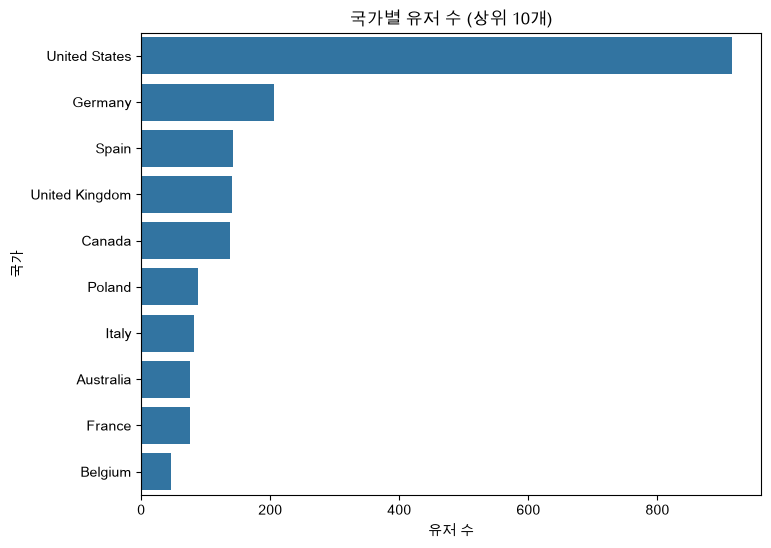

In [ ]:
top_countries = user_info["country"].value_counts()
print(f"country 결측: {user_info['country'].isna().sum()}명 ({user_info['country'].isna().mean():.1%})")
print(f"stateorprovince 결측: {user_info['stateorprovince'].isna().sum()}명 ({user_info['stateorprovince'].isna().mean():.1%})")
print(f"distinct countries: {user_info['country'].nunique()}개")

plt.figure(figsize=(8, 6))
sns.barplot(x=top_countries.head(10).values, y=top_countries.head(10).index)
plt.title("국가별 유저 수 (상위 10개)")
plt.xlabel("유저 수")
plt.ylabel("국가")
plt.show()

lastlogin 결측: 2명
lastlogin 범위: 2004-03-22 ~ 2026-09-02


count    2998.000000
mean      267.853569
std       791.363808
min         2.000000
25%         3.000000
50%         4.000000
75%        62.000000
max      8201.000000
Name: days_since_login, dtype: float64

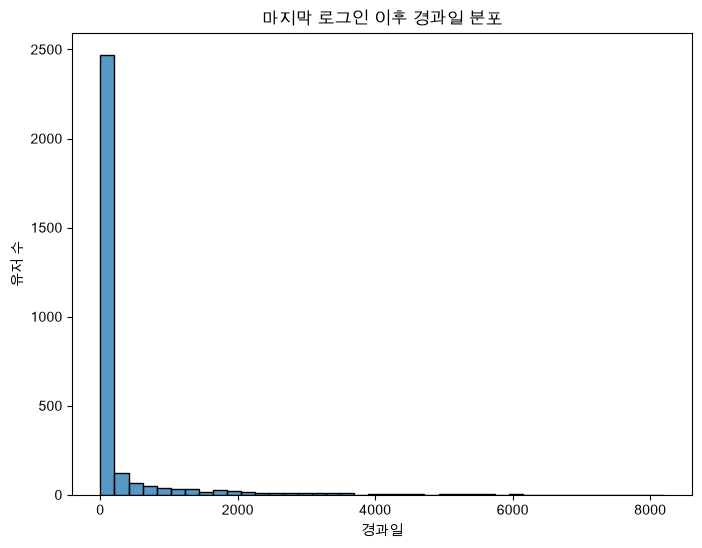

In [ ]:
user_info["lastlogin_dt"] = pd.to_datetime(user_info["lastlogin"], errors="coerce")
today = pd.Timestamp("2026-09-04")
user_info["days_since_login"] = (today - user_info["lastlogin_dt"]).dt.days

print(f"lastlogin 결측: {user_info['lastlogin_dt'].isna().sum()}명")
print(f"lastlogin 범위: {user_info['lastlogin_dt'].min().date()} ~ {user_info['lastlogin_dt'].max().date()}")
display(user_info["days_since_login"].describe())

plt.figure(figsize=(8, 6))
sns.histplot(data=user_info, x="days_since_login", bins=40)
plt.title("마지막 로그인 이후 경과일 분포")
plt.xlabel("경과일")
plt.ylabel("유저 수")
plt.show()

**결과**
- `yearregistered` 범위 1999~2026년으로 확인
- `traderating` 중앙값 0, 평균 8.7, 최댓값 989로 롱테일 형태로 확인
- `country` 542명(18.1%) 결측, 77개국 중 미국이 압도적 다수로 확인
    - 지역별 분석 시 이 쏠림을 감안
- `lastlogin` 2명만 결측, 범위 2004-03-22~2026-09-02로 확인
- 마지막 로그인 이후 경과일 분포는 [Funnel 분석](02.Funnel_Retention.ipynb)·[Segment 분석](03.Segment_Wishlist.ipynb)에서 활동 감소 판정 기준을 정하는 근거로 사용


<a id="sec-1-3"></a>
### 1-3. 이상치 (`traderating`)

- `traderating`(거래 평판 점수)이 극단치인지, 아니면 이 데이터에서는 원래 이런 분포인지 확인

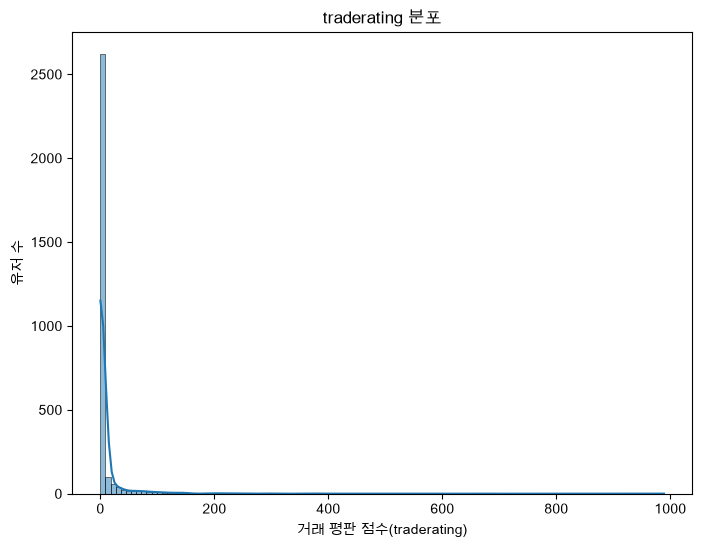

traderating 최빈값: 0 (비율 76.6%)


,column,n_samples,statistic,p_value,is_normal,skewness,kurtosis
0,traderating,3000,0.2116,0.0,False,11.4588,196.9391


In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=user_info, x='traderating', fill=True, kde=True)
plt.title("traderating 분포")
plt.xlabel("거래 평판 점수(traderating)")
plt.ylabel("유저 수")
plt.show()

trader_row = user_info_num_summary[user_info_num_summary['columns'] == 'traderating'].iloc[0]
print(f"traderating 최빈값: {trader_row['mode_value']} (비율 {trader_row['mode_ratio']}%)")
AdvanceEDA.shapiro_test(user_info[['traderating']])

**결과**
- `traderating`이 0인 유저 76.6%로 확인
    - 대부분의 유저는 BGG 거래 기능 자체를 사용하지 않는 것으로 나타남
- 통계적으로도 극단적 우측왜도로 확인(Shapiro p=0, 왜도 11.46·첨도 196.9)
- 이는 이상치라기보다 거래를 하는 소수에게만 의미 있는 지표라는 것을 시사
- 핵심 지표 후보에서 제외


<a id="sec-1-4"></a>
### 1-4. 가입연도 흐름

- 가입연도가 특정 시기에 몰려 있는지, 그리고 그 흐름에 눈에 띄는 변곡점이 있는지 확인

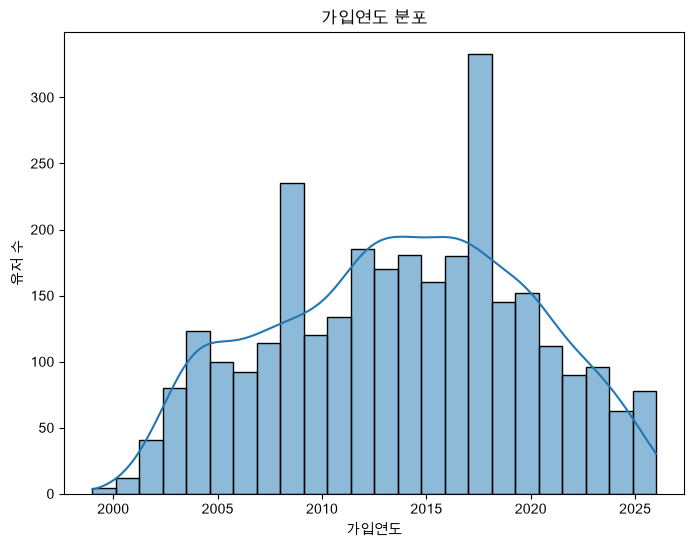

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=user_info, x='yearregistered', bins=24, kde=True)
plt.title("가입연도 분포")
plt.xlabel("가입연도")
plt.ylabel("유저 수")
plt.show()

In [ ]:
yearly_counts = user_info["yearregistered"].value_counts().sort_index()
display(yearly_counts.rename("인원"))

peak_year = yearly_counts.idxmax()
print(f"가입자 최고점: {peak_year}년 ({yearly_counts.max()}명)")

for a, b in [(2018, 2019), (2019, 2020), (2020, 2021), (2021, 2022)]:
    diff = int(yearly_counts.get(b, 0)) - int(yearly_counts.get(a, 0))
    print(f"{a}→{b}년 증감: {diff:+d}명")

yearregistered
1999      1
2000      3
2001     12
2002     41
2003     80
2004    123
2005    100
2006     92
2007    114
2008    112
2009    123
2010    120
2011    134
2012    185
2013    170
2014    181
2015    160
2016    180
2017    182
2018    151
2019    145
2020    152
2021    112
2022     90
2023     96
2024     63
2025     59
2026     19
Name: 인원, dtype: int64

가입자 최고점: 2012년 (185명)
2018→2019년 증감: -6명
2019→2020년 증감: +7명
2020→2021년 증감: -40명
2021→2022년 증감: -22명


**결과**
- 가입자 최고점은 2012년(185명)으로 확인, 이후 완만히 감소
- 2016~2020년은 145~182명 사이 정체 구간으로 확인
- 2019→2020년 소폭 반등(+7명), 2021년 급감(-40명)으로 확인
    - 2020년은 코로나로 실내 활동이 늘던 시기와 겹치지만, 반등 폭이 전체 3,000명 기준 7명뿐이라 우연한 변동과 구분하기 어려움
- 오히려 뚜렷한 건 회복 없는 2021년 급감과 이후(2022~) 지속적인 감소세로 확인
- 데이터 수집이 마지막으로 진행된 시점(2026-09) 기준이라 최근 연도일수록 아직 다 모이지 않은 절단 효과가 섞여 있음
- 이는 최근 감소를 곧바로 활동 위축의 심화로 해석할 수 없다는 것을 시사


<a id="sec-1-5"></a>
### 1-5. 보유 게임 행동(`user_item`)

- 유저가 실제로 뭘 갖고 뭘 하는가
- 지금까지는 `user_activity`(유저별 합계)로만 보유 게임을 스쳐봤다. 
- 원본은 15개 컬럼짜리 131만 행

In [ ]:
print(f"shape: {user_item_raw.shape}")
display(user_item_raw.head())

for c in ["own", "prevowned", "fortrade", "want", "wanttoplay", "wanttobuy", "wishlist", "preordered"]:
    print(f"{c}: {user_item_raw[c].value_counts(dropna=False).to_dict()}")

shape: (1309380, 15)


,user_id,objectid,user_rating,numplays,comment,own,prevowned,fortrade,want,wanttoplay,wanttobuy,wishlist,wishlistpriority,preordered,lastmodified
0,Sar2229,366994,7.0,1,NaN,True,False,False,False,False,False,False,NaN,False,2026-05-11 17:32:04
1,Sar2229,276633,NaN,0,playing tiles,True,False,False,False,False,False,False,NaN,False,2025-12-21 15:46:41
2,playr2,365500,NaN,0,NaN,True,False,False,False,False,False,False,NaN,False,2023-07-14 10:38:40
3,musical_racket,348096,8.0,0,NaN,True,False,False,False,False,False,False,NaN,False,2024-03-21 16:02:44
4,musical_racket,298562,NaN,0,NaN,True,False,False,False,False,False,False,NaN,False,2025-01-21 09:52:41


own: {True: 1309380}
prevowned: {False: 1302477, True: 6903}
fortrade: {False: 1271268, True: 38112}
want: {False: 1308530, True: 850}
wanttoplay: {False: 1276735, True: 32645}
wanttobuy: {False: 1308735, True: 645}
wishlist: {False: 1306175, True: 3205}
preordered: {False: 1302589, True: 6791}


**결과**
- `own` 100% TRUE로 확인
    - 이 수집은 own=1 조건의 보유 게임 목록 전용이라는 뜻
- `wishlist` 플래그가 3,205행뿐인 것도 같은 이유로 확인
    - 보유 게임 목록 API 응답에는 위시 전용 게임(보유하지 않고 위시리스트에만 담은 게임)이 아예 안 잡힘
- 이는 별도로 wishlist=1 수집이 필요한 구조적 이유를 보여줌


In [ ]:
dup_mask = user_item_raw.duplicated(subset=["user_id", "objectid"], keep=False)
print(f"중복 (user_id, objectid) 쌍: {user_item_raw.duplicated(subset=['user_id','objectid']).sum():,}건")
display(user_item_raw[dup_mask].sort_values(["user_id", "objectid"]).head(4)
        [["user_id", "objectid", "user_rating", "numplays", "lastmodified"]])

중복 (user_id, objectid) 쌍: 13,861건


,user_id,objectid,user_rating,numplays,lastmodified
109026,2lip,318243,4.0,3,2025-07-02 13:04:17
847187,2lip,318243,NaN,3,2025-07-02 12:43:47
481820,521tiger,4230,7.0,19,2019-04-16 05:27:57
1264226,521tiger,4230,10.0,19,2013-07-18 02:15:03


**결과**
- 중복 `(user_id, objectid)` 쌍 13,861건 확인
- 같은 게임을 여러 번(다른 코멘트·평점 시점) 기록한 행으로 확인


numplays=0 (소유했지만 미플레이): 940,727건 (71.8%)
user_rating 채워짐: 691,432건 (52.8%)


count    691432.000000
mean          7.437692
std           1.390098
min           1.000000
25%           7.000000
50%           7.500000
75%           8.000000
max          10.000000
Name: user_rating, dtype: float64

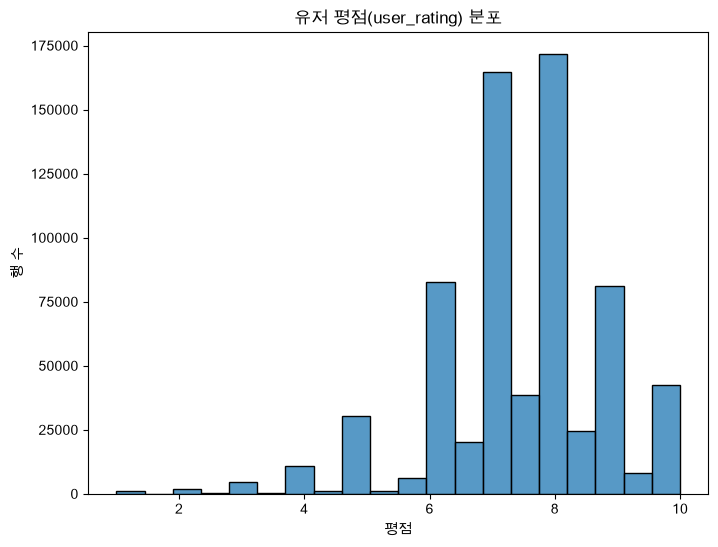

comment 채워짐: 14.1%
lastmodified 범위: 2001-06-11 15:15:52 ~ 2026-09-02 21:19:58


In [ ]:
unplayed = (user_item_raw["numplays"] == 0).sum()
print(f"numplays=0 (소유했지만 미플레이): {unplayed:,}건 ({unplayed/len(user_item_raw):.1%})")

rated = user_item_raw["user_rating"].notna()
print(f"user_rating 채워짐: {rated.sum():,}건 ({rated.mean():.1%})")
display(user_item_raw.loc[rated, "user_rating"].describe())

plt.figure(figsize=(8, 6))
sns.histplot(data=user_item_raw[rated], x="user_rating", bins=20)
plt.title("유저 평점(user_rating) 분포")
plt.xlabel("평점")
plt.ylabel("행 수")
plt.show()

comment_rate = user_item_raw["comment"].notna().mean()
print(f"comment 채워짐: {comment_rate:.1%}")
print(f"lastmodified 범위: {user_item_raw['lastmodified'].min()} ~ {user_item_raw['lastmodified'].max()}")

**결과**
- `numplays=0`(보유는 하지만 플레이 기록 없음)이 940,727건(71.8%)으로 확인
    - "사놓고 기록 없음"의 원자료이자 [Funnel 분석](02.Funnel_Retention.ipynb) 퍼널의 출발점
- `user_rating`은 52.8%만 채워진 것으로 확인
    - 채워진 값은 중앙값 7.5 근방에 몰려 있음
    - 왜 절반만 채워지는지는 이 데이터만으로 알 수 없어, 평가 여부는 커뮤니티 참여 성향을 나타내는 별도 지표로 다룬다(8-3에서 퍼널 단계가 아닌 이유를 실측으로 확인)
- `comment` 14.1%, `lastmodified` 100% 채워짐(2001-06-11~2026-09-02)으로 확인


In [ ]:
users_with_items = set(user_item_raw["user_id"].unique())
users_all = set(user_info["user_id"].unique())
zero_item_users = users_all - users_with_items
print(f"user_info {len(users_all):,}명 중 컬렉션이 0건인 유저: {len(zero_item_users):,}명")

user_info 3,000명 중 컬렉션이 0건인 유저: 56명


**결과**
- `user_info` 3,000명 중 56명은 보유 게임이 0건으로 확인
- 이들은 [Funnel 분석](02.Funnel_Retention.ipynb) 퍼널의 "0단계"(수집은 됐지만 보유 기록 자체가 없는 유저)에 해당


<a id="sec-1-6"></a>
### 1-6. 실제 플레이 행동(`user_play`)

- 얼마나, 어떻게 했는가?
- 0 plays 대상으로 선정한 1,065명(코호트별로 고르게 뽑음)을 대상으로 실제 플레이 로그를 직접 수집한 테이블
- `numplays`(보유 게임 기록에 적힌 누적 횟수)와 달리 **개별 플레이 건**(날짜/소요시간 포함) 시계열 분석이 여기서 시작

In [ ]:
print(f"shape: {user_play_raw.shape}")
display(user_play_raw.head())

n_play_users = user_play_raw["user_id"].nunique()
n_sample_users = len(pd.read_csv(DATA_DIR / "plays_sample_users.csv"))
print(f"plays 대상 {n_sample_users:,}명 중 실제 플레이 기록이 있는 유저: {n_play_users:,}명")
print(f"게임 수: {user_play_raw['objectid'].nunique():,}개")

shape: (1272008, 8)


,play_id,user_id,objectid,play_date,quantity,length,incomplete,location
0,7770384,28green,23964,2012-07-11,1,0,False,NaN
1,9808839,28green,25669,2013-07-17,1,0,False,NaN
2,12165718,28green,2653,2014-07-05,1,0,False,NaN
3,7990512,28green,2653,2012-08-25,1,0,False,NaN
4,10842041,28green,2655,2014-01-02,2,0,False,NaN


plays 대상 1,065명 중 실제 플레이 기록이 있는 유저: 730명
게임 수: 39,801개


**결과**
- plays 대상 1,065명 중 실제 플레이 기록이 있는 유저는 730명으로 확인


In [ ]:
user_play_raw["play_date_dt"] = pd.to_datetime(user_play_raw["play_date"], errors="coerce")
print(f"play_date 결측: {user_play_raw['play_date_dt'].isna().sum():,}건")
print(f"play_date 범위(원본): {user_play_raw['play_date_dt'].min()} ~ {user_play_raw['play_date_dt'].max()}")

valid_range = user_play_raw[
    (user_play_raw["play_date_dt"] >= "2001-01-01") & (user_play_raw["play_date_dt"] <= "2026-09-04")
]
print(f"정상 구간(2001~2026-09-04) 필터 후: {len(valid_range):,}건 ({len(valid_range)/len(user_play_raw):.1%})")

length_pos = (user_play_raw["length"] > 0).sum()
print(f"length>0 (소요시간 실제 기록): {length_pos:,}건 ({length_pos/len(user_play_raw):.1%}) — 나머지는 0(결측 마커)")

print(f"quantity 최댓값: {user_play_raw['quantity'].max():,}")
print(f"incomplete=True: {user_play_raw['incomplete'].sum():,}건")
print(f"location 채워짐: {user_play_raw['location'].notna().mean():.1%}")

play_date 결측: 1,573건
play_date 범위(원본): 0001-01-01 00:00:00 ~ 2027-07-03 00:00:00


정상 구간(2001~2026-09-04) 필터 후: 1,266,896건 (99.6%)
length>0 (소요시간 실제 기록): 260,493건 (20.5%) — 나머지는 0(결측 마커)
quantity 최댓값: 3,000
incomplete=True: 3,628건
location 채워짐: 49.0%


**결과**
- `play_date` 원본 범위가 0001-01-01~2027-07-03로 양끝 오염 확인(NULL 1,573건 포함)
- 정상 구간(2001~2026-09-04) 필터 후 1,266,896건(99.6%) 남는 것으로 확인
- `length`(소요시간)는 100% non-NULL이지만 `>0`은 20.5%뿐으로 확인
    - 나머지 79.5%는 기록을 안 남긴 결측이라, 그대로 평균 내면 5배 가까이 왜곡됨
- `location` 49.0%만 채워짐, `incomplete=True`(중도포기) 3,628건으로 확인


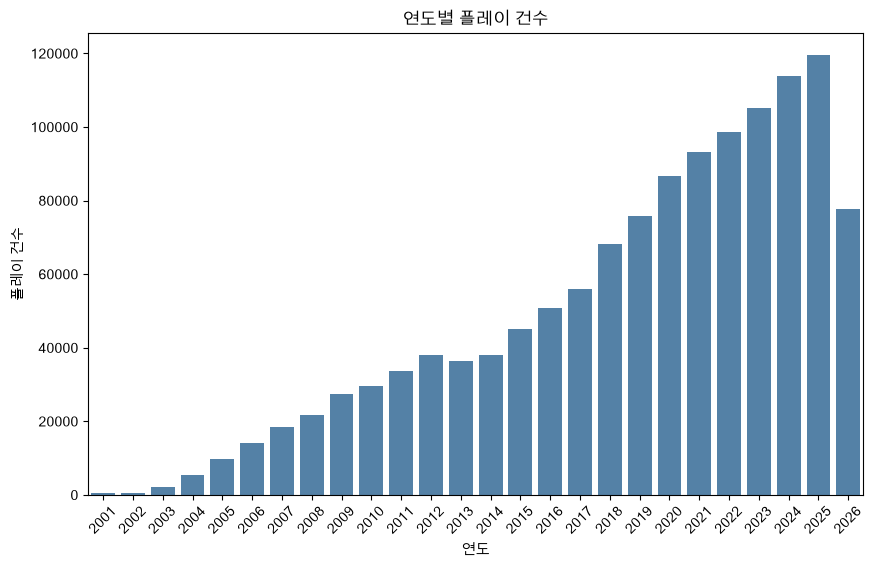

In [ ]:
yearly = valid_range.groupby(valid_range["play_date_dt"].dt.year).size()

plt.figure(figsize=(10, 6))
sns.barplot(x=yearly.index.astype(str), y=yearly.values, color="steelblue")
plt.title("연도별 플레이 건수")
plt.xlabel("연도")
plt.ylabel("플레이 건수")
plt.xticks(rotation=45)
plt.show()

**결과**
- 연도별 플레이 건수는 최근 연도로 갈수록 늘어나는 형태로 확인
- 이는 플레이 로그 자체가 최근 활동 유저 위주로 수집된 결과(최근 로그인 기준으로 코호트를 뽑음)일 수 있어, 그 점을 감안해서 읽는다


<a id="sec-1-7"></a>
### 1-7. 위시리스트(`user_wishlist`)

- 1-5에서 확인했듯 소유 게임 목록(own=1) 수집에는 위시 전용 게임이 잡히지 않는다. 그래서 별도로 `wishlist=1` 조건으로 보강 수집한 테이블이다.
- 퍼널에는 쓰지 않는다: 3,000명 중 1,884명만 있고, `user_rating`과 같은 이유로 위시 **등록 시점이 없어** 순서를 만들 수 없다.

In [ ]:
print(f"shape: {user_wishlist_raw.shape}")
print(f"유저 수: {user_wishlist_raw['user_id'].nunique():,}명 (user_info 3,000명 중)")
print(f"게임 수: {user_wishlist_raw['objectid'].nunique():,}개")
print(f"own=1(사실은 소유 중인데 위시로도 잡힌 행): {(user_wishlist_raw['own'] == 1).sum():,}건 ({(user_wishlist_raw['own'] == 1).mean():.1%})")
print(f"wishlistpriority 분포:")
display(user_wishlist_raw['wishlistpriority'].value_counts(dropna=False).sort_index())

shape: (160565, 5)
유저 수: 1,884명 (user_info 3,000명 중)
게임 수: 44,231개
own=1(사실은 소유 중인데 위시로도 잡힌 행): 3,204건 (2.0%)
wishlistpriority 분포:


wishlistpriority
0        4
1    17688
2    18056
3    69392
4    30471
5    24954
Name: count, dtype: int64

**결과**
- `user_wishlist` 160,565행, 유저 1,884명, 게임 44,231개로 확인
- 98.0%(157,361행)는 순수 위시(보유 안 함), 2.0%는 이미 보유 중인데 위시로도 남은 행으로 확인
- [Segment 분석](03.Segment_Wishlist.ipynb)에서 "관심은 있지만 아직 안 산 게임" 분석 자산으로 남겨두고, 이 노트북의 퍼널에는 포함하지 않는다


<a id="sec-2"></a>
## 2. 게임 데이터의 구조와 함정

- 기본 정보부터 카테고리 및 순위 체계까지, 게임 쪽 데이터를 훑는다.

<a id="sec-2-1"></a>
### 2-1. 기본 정보

In [ ]:
print(f"shape: {item_wide.shape}")
display(item_wide.info())
display(item_wide.head())

shape: (80127, 20)
<class 'pandas.DataFrame'>
RangeIndex: 80127 entries, 0 to 80126
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objectid       80127 non-null  int64  
 1   name           80127 non-null  str    
 2   yearpublished  80127 non-null  int64  
 3   minplayers     78613 non-null  float64
 4   maxplayers     77560 non-null  float64
 5   minplaytime    70056 non-null  float64
 6   maxplaytime    68839 non-null  float64
 7   playingtime    70171 non-null  float64
 8   numowned       80127 non-null  int64  
 9   rank           29644 non-null  float64
 10  usersrated     80127 non-null  int64  
 11  average        80127 non-null  float64
 12  bayesaverage   80127 non-null  float64
 13  stddev         80127 non-null  float64
 14  owned          80127 non-null  int64  
 15  wishing        80127 non-null  int64  
 16  averageweight  80127 non-null  float64
 17  numweights     80127 non-null  int64  
 18

None

,objectid,name,yearpublished,minplayers,maxplayers,minplaytime,maxplaytime,playingtime,numowned,rank,usersrated,average,bayesaverage,stddev,owned,wishing,averageweight,numweights,minage,avg_weights
0,19494,Federation & Empire: Planetary Operations,2005,2.0,NaN,NaN,NaN,NaN,123,NaN,28,7.60714,0.00000,1.51985,123,19,4.3333,3,12,4.3333
1,265700,Reality's Edge: Cyberpunk Skirmish Rules,2019,2.0,NaN,NaN,NaN,NaN,162,19545.0,31,7.93548,5.52040,1.83049,162,34,3.4000,5,0,3.4000
2,108633,HeroClix: The Lord of the Rings,2011,2.0,NaN,NaN,NaN,NaN,258,NaN,78,7.10244,5.53830,1.59567,258,21,2.8000,5,0,2.8000
3,30684,Johnny Reb,1983,2.0,NaN,NaN,NaN,NaN,276,15950.0,77,6.91169,5.53439,1.68608,275,10,3.1111,9,0,3.1111
4,25964,Star Fleet Battles: Captain's Yeoman – Captain...,2003,NaN,NaN,NaN,NaN,NaN,114,NaN,25,8.40800,0.00000,1.08772,114,12,4.2000,5,12,4.2000


In [ ]:
item_summary = basic_eda.run(item_wide)
item_str_summary = item_summary[item_summary['dtype'].apply(pd.api.types.is_string_dtype)].reset_index(drop=True)
item_num_summary = item_summary[(item_summary['dtype'] == 'int') | (item_summary['dtype'] == 'float')].reset_index(drop=True)

print(f"Str Type: {item_str_summary.shape[0]}")
print(f"Number Type: {item_num_summary.shape[0]}")

Str Type: 1
Number Type: 19


In [ ]:
display(item_str_summary)
display(item_num_summary)

,columns,missing_ratio,mode_value,mode_ratio,unique_cnt,dtype
0,name,0.0,Robin Hood,0.01,78721,str


,columns,missing_ratio,mode_value,mode_ratio,unique_cnt,dtype
0,objectid,0.00,1,0.00,80127,int64
1,yearpublished,0.00,2019,5.57,254,int64
2,minplayers,1.89,2.0,60.85,13,float64
3,maxplayers,3.20,4.0,30.26,65,float64
4,minplaytime,12.57,30.0,18.40,112,float64
5,maxplaytime,14.09,30.0,14.56,175,float64
6,playingtime,12.43,30.0,15.00,176,float64
7,numowned,0.00,7,0.84,6703,int64
8,rank,63.00,2661.0,0.00,29547,float64
9,usersrated,0.00,2,3.24,4247,int64


In [ ]:
item_wide.describe()

,objectid,yearpublished,minplayers,maxplayers,minplaytime,maxplaytime,playingtime,numowned,rank,usersrated,average,bayesaverage,stddev,owned,wishing,averageweight,numweights,minage,avg_weights
count,80127.000000,80127.000000,78613.000000,77560.000000,70056.000000,6.883900e+04,7.017100e+04,80127.000000,29644.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000,80127.000000
mean,209909.390405,1979.980281,1.881941,6.268773,57.674832,5.686206e+02,5.587011e+02,969.195015,15188.920692,426.468594,6.626308,2.961492,1.397890,966.996855,127.644627,1.417465,19.866050,9.065533,1.417465
std,147106.678811,252.402777,0.736047,16.021795,645.481415,1.146574e+05,1.135639e+05,4520.741013,8993.058603,2770.037577,1.497321,2.844412,0.561758,4512.498559,626.974148,1.186168,130.689187,4.687569,1.186168
min,1.000000,-3500.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,56018.000000,2007.000000,1.000000,3.000000,20.000000,3.000000e+01,3.000000e+01,42.000000,7412.750000,9.000000,6.000000,0.000000,1.187320,42.000000,5.000000,0.000000,0.000000,7.000000,0.000000
50%,211882.000000,2016.000000,2.000000,4.000000,30.000000,4.500000e+01,4.500000e+01,144.000000,14893.500000,33.000000,6.833330,5.483100,1.415920,143.000000,16.000000,1.409100,2.000000,10.000000,1.409100
75%,337503.500000,2021.000000,2.000000,6.000000,60.000000,9.000000e+01,9.000000e+01,519.000000,22884.250000,129.000000,7.560070,5.554130,1.673990,517.000000,59.000000,2.250000,7.000000,12.000000,2.250000
max,478511.000000,2030.000000,22.000000,1000.000000,157680.000000,3.000000e+07,3.000000e+07,244243.000000,31235.000000,143907.000000,10.000000,8.493560,4.500000,243779.000000,27385.000000,5.000000,8664.000000,196.000000,5.000000


**결과**
- `rank`는 63.0%가 NULL("Not Ranked")로 확인
    - 랭킹 기반 분석은 실제로 순위가 매겨진 37.0%(29,644개)만 대상
- `minage`·`avg_weights`는 요약 도구의 `missing_ratio`가 0%로 잡히는 것으로 확인
    - 실제로는 NaN이 아니라 0으로 채워진 결측이라 놓치기 쉬움
- `item_details.avg_weights`와 `item_stats.averageweight`는 서로 다른 컬럼으로 확인


<a id="sec-2-2"></a>
### 2-2. 이상치

- 확인 대상: `yearpublished`, `averageweight`([2-1](#sec-2-1) 이상값), `numowned` vs `owned`, `stddev`, `minage`

**A. `averageweight = 0`**
1~5 척도인데 0이 다수.
결측인가 값인가?

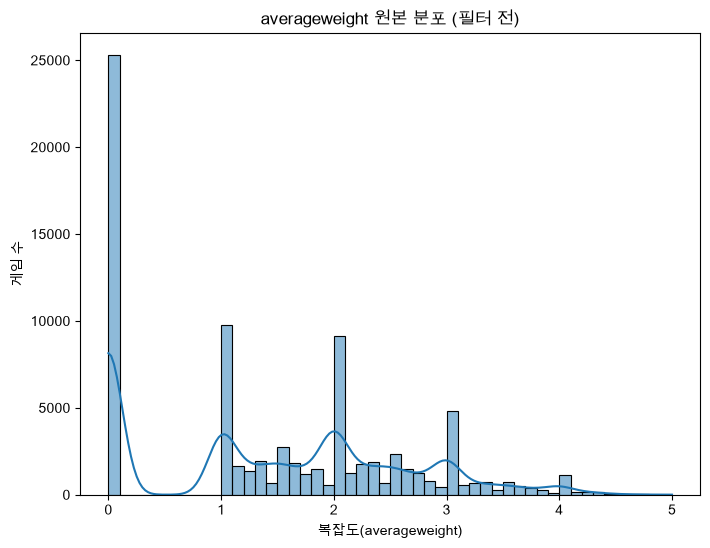

averageweight=0: 25,321건
그중 numweights(채점자 수)도 0인 비율: 100.0%


In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=item_wide, x='averageweight', bins=50, kde=True)
plt.title("averageweight 원본 분포 (필터 전)")
plt.xlabel("복잡도(averageweight)")
plt.ylabel("게임 수")
plt.show()

zero_mask = item_wide['averageweight'] == 0
print(f"averageweight=0: {zero_mask.sum():,}건")
print(f"그중 numweights(채점자 수)도 0인 비율: {(item_wide.loc[zero_mask, 'numweights'] == 0).mean():.1%}")

In [ ]:
item = item_wide[item_wide['averageweight'] > 0].copy()
print(f"item_wide {len(item_wide):,}행 → item {len(item):,}행 ({len(item_wide) - len(item):,}건 제외)")

item_wide 80,127행 → item 54,806행 (25,321건 제외)


In [ ]:
naive_light = (item_wide['averageweight'] <= 1.5).mean()
correct_light = (item['averageweight'] <= 1.5).mean()
print(f"naive(0을 '매우 쉬움'으로 포함): 가벼움 비율 {naive_light:.1%}")
print(f"correct(0 제외): 가벼움 비율 {correct_light:.1%}")

naive(0을 '매우 쉬움'으로 포함): 가벼움 비율 53.5%
correct(0 제외): 가벼움 비율 32.0%


In [ ]:
zero_stddev = (item_wide["stddev"] == 0).sum()
zero_minage = (item_wide["minage"] == 0).sum()
zero_avgw_details = (item_wide["avg_weights"] == 0).sum()
print(f"stddev=0: {zero_stddev:,}건 (평가자 1명 이하로 분산을 계산할 수 없는 경우)")
print(f"minage=0: {zero_minage:,}건 ({zero_minage/len(item_wide):.1%}) — 결측 마커, '0세부터'가 아니다")
print(f"item_details.avg_weights=0: {zero_avgw_details:,}건 ({zero_avgw_details/len(item_wide):.1%})"
      f" — item_stats.averageweight와는 다른 컬럼. 이 노트북은 averageweight를 표준으로 쓴다")

stddev=0: 4,700건 (평가자 1명 이하로 분산을 계산할 수 없는 경우)
minage=0: 11,689건 (14.6%) — 결측 마커, '0세부터'가 아니다
item_details.avg_weights=0: 25,321건 (31.6%) — item_stats.averageweight와는 다른 컬럼. 이 노트북은 averageweight를 표준으로 쓴다


**결과**

**A. `averageweight = 0`**
- 25,321건(31.6%)이 0으로 확인, 이 중 100%가 `numweights`(복잡도 채점자 수)도 0
- 이는 "매우 쉬운 게임"이 아니라 "아무도 복잡도를 평가하지 않은 게임"이라는 것을 시사
- 0을 포함하면 "가벼움" 비율 53.5%, 제외하면 32.0%로 21.5%p 차이 확인
    - 앞으로 복잡도 관련 분석은 이 25,321건을 제외한 `item`(54,806행)을 사용
- 같은 함정 2곳 추가 확인: `minage=0` 11,689건(14.6%), `stddev=0` 4,700건(평가자 1명 이하라 분산 계산 불가)
- 셋 다 "값이 0"이 아니라 "잴 수 없어서 0으로 채운" 결측 마커로 확인

**B. `yearpublished` 최솟값**
오류인가 실제 값인가?


In [ ]:
item_wide.nsmallest(10, 'yearpublished')[['name', 'yearpublished']]

,name,yearpublished
2236,Senet,-3500
21831,Marbles,-3000
47757,Knucklebones,-3000
53482,Mehen,-3000
63273,Backgammon,-3000
1762,The Royal Game of Ur,-2600
4122,Go,-2200
49193,Five Stones,-2000
1018,Three Men's Morris,-1400
1388,Nine Men's Morris,-1400


In [ ]:
pre1900 = item_wide[item_wide["yearpublished"] < 1900]
breakdown = pd.Series({
    "0 (결측 마커)": (pre1900["yearpublished"] == 0).sum(),
    "음수 (실제 고대게임)": (pre1900["yearpublished"] < 0).sum(),
    "1~1899": ((pre1900["yearpublished"] > 0) & (pre1900["yearpublished"] < 1900)).sum(),
})
print(f"yearpublished < 1900: {len(pre1900):,}건 ({len(pre1900)/len(item_wide):.2%})")
display(breakdown.rename("게임 수"))

future = item_wide[item_wide["yearpublished"] > 2026]
print(f"yearpublished > 2026 (발매예정): {len(future):,}건")
display(future["yearpublished"].value_counts().sort_index())

yearpublished < 1900: 1,457건 (1.82%)


0 (결측 마커)       1198
음수 (실제 고대게임)      16
1~1899           243
Name: 게임 수, dtype: int64

yearpublished > 2026 (발매예정): 113건


yearpublished
2027    112
2030      1
Name: count, dtype: int64

**결과**

- `yearpublished < 1900`은 1,457건(1.82%)으로 확인, 대부분 결측으로 구성
    - 0(결측 마커) 1,198건(82.2%), 음수(Senet -3500, Backgammon -3000, Go -2200 등 실제 고대 보드게임) 16건, 1~1899년 실제 발매작 243건
- 반대쪽 끝도 확인: `yearpublished > 2026`(발매예정작) 113건(2027년 112개, 2030년 1개)
    - 트렌드 분석 컷오프는 양쪽 다 감안해야 한다는 것을 시사

**C. `numowned` vs `owned` 불일치**
둘 다 "BGG 전체 소유자 수"인데 같은 값인가?


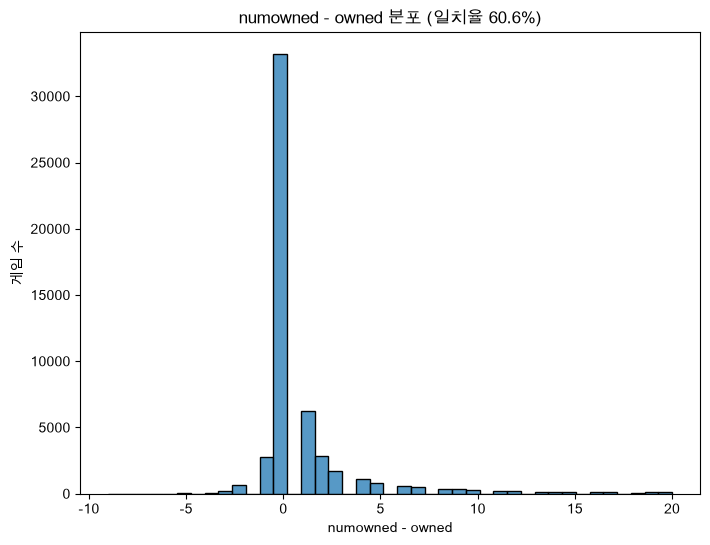

평균 절대 차이: 3.21


In [ ]:
diff = item['numowned'] - item['owned']
match_rate = (diff == 0).mean()

plt.figure(figsize=(8, 6))
sns.histplot(diff[diff.abs() <= 20], bins=41)
plt.title(f"numowned - owned 분포 (일치율 {match_rate:.1%})")
plt.xlabel("numowned - owned")
plt.ylabel("게임 수")
plt.show()

print(f"평균 절대 차이: {diff.abs().mean():.2f}")

**결과**
- `numowned`와 `owned` 평균 절대 차이 3.21로 확인
- 사실상 같은 지표를 다른 시점 스냅샷에서 집계한 것으로 판단, 이후 분석에서는 `owned`를 표준으로 사용


In [ ]:
zero_bayes = (item_wide["bayesaverage"] == 0).sum()
print(f"bayesaverage=0: {zero_bayes:,}건 ({zero_bayes/len(item_wide):.1%})")

min_rated_when_valid = item_wide.loc[item_wide["bayesaverage"] > 0, "usersrated"].min()
max_rated_when_zero = item_wide.loc[item_wide["bayesaverage"] == 0, "usersrated"].max()
print(f"bayesaverage>0인 게임의 usersrated 최솟값: {min_rated_when_valid}")
print(f"bayesaverage=0인 게임의 usersrated 최댓값: {max_rated_when_zero}")

zero_bayes_in_item = (item["bayesaverage"] == 0).sum()
print(f"복잡도 유효(item, {len(item):,}행) 안에서도 bayesaverage=0: {zero_bayes_in_item:,}건 ({zero_bayes_in_item/len(item):.1%})")

bayesaverage=0: 38,306건 (47.8%)
bayesaverage>0인 게임의 usersrated 최솟값: 30
bayesaverage=0인 게임의 usersrated 최댓값: 29
복잡도 유효(item, 54,806행) 안에서도 bayesaverage=0: 16,083건 (29.3%)


**D. `bayesaverage = 0`**

- 38,306건(47.8%)이 0이다. `bayesaverage > 0`인 게임의 `usersrated` 최솟값은 30, `bayesaverage = 0`인 게임의 `usersrated` 최댓값은 29 — **BGG는 평가자 30명 미만 게임에 베이즈 평균을 아예 산출하지 않는다.**
- 즉 0은 "평점 0점"이 아니라 **임계 미달로 애초에 계산되지 않은 값(미산출)**이다. `averageweight`·`minage`·`stddev`와 같은 성격의 결측 마커다.
- **확정 기준**: 이후 평점 비교·차이·상관 분석은 전부 `bayesaverage > 0`(= `usersrated ≥ 30`)에서만 수행한다(6-1·6-2·6-3·6-4에 적용).

<a id="sec-2-3"></a>
### 2-3. 분포/정규성 확인

- 각 변수가 어떤 분포를 따르는지 먼저 확인

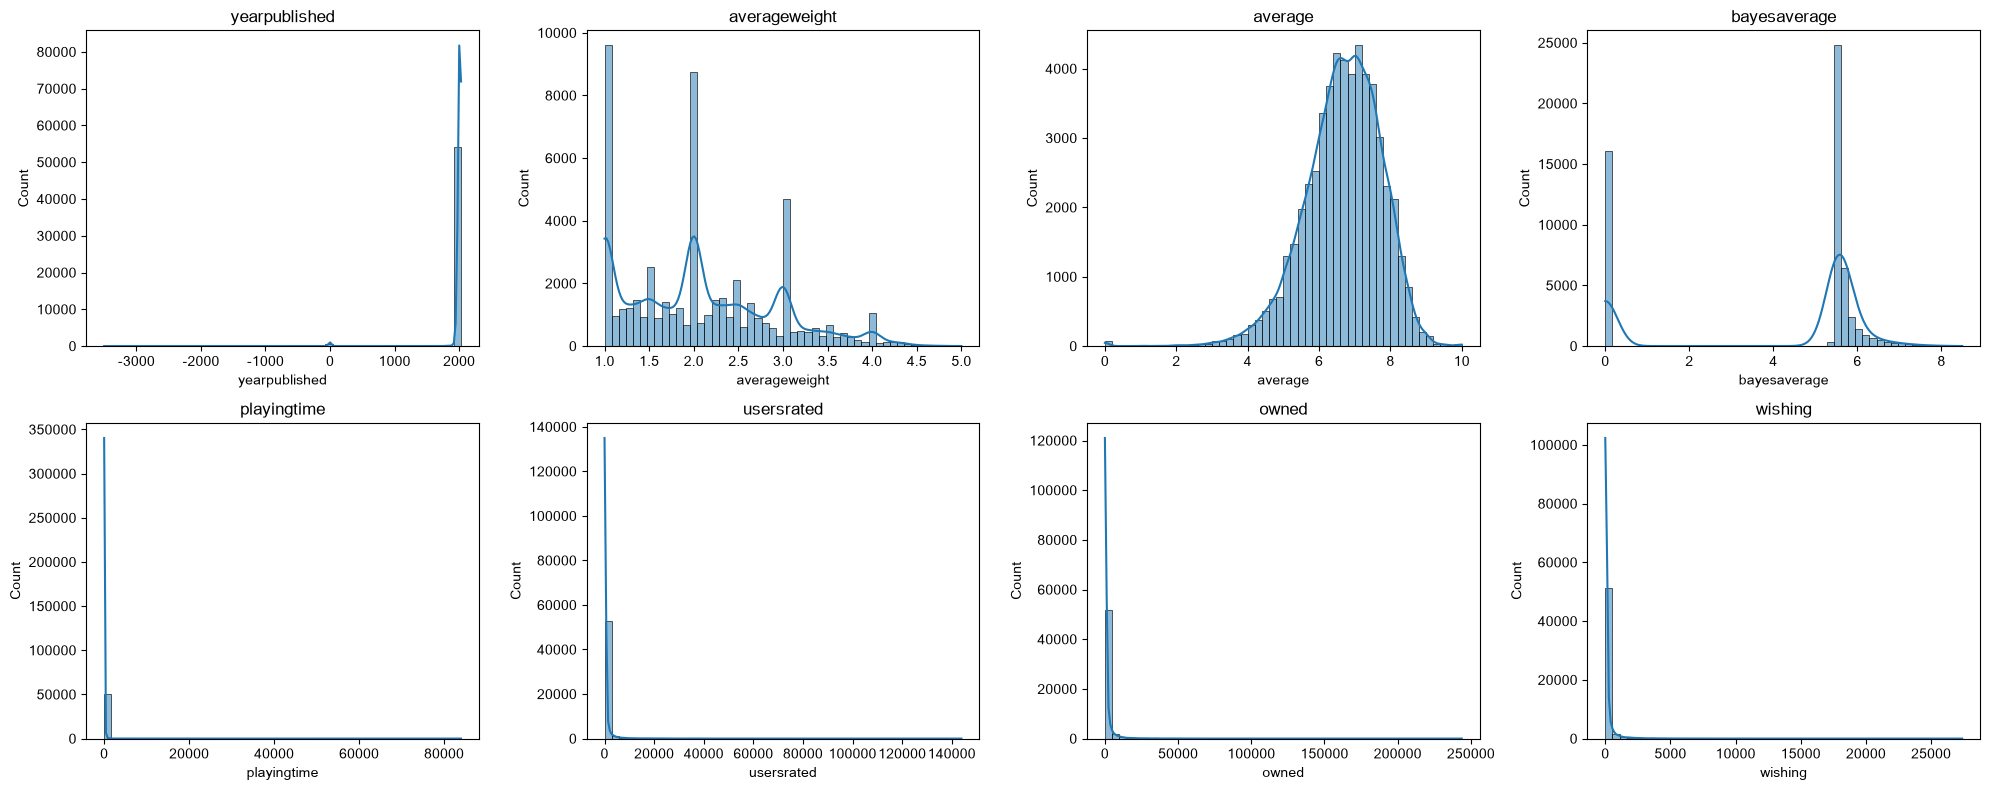

,column,n_samples,statistic,p_value,is_normal,skewness,kurtosis
0,yearpublished,54806,0.1092,0.0,False,-10.2843,118.5721
1,averageweight,54806,0.9859,0.0,False,0.5197,-0.4386
2,average,54806,0.9904,0.0,False,-0.7513,2.1446
3,bayesaverage,54806,0.4811,0.0,False,-0.8624,-1.1756
4,playingtime,50296,0.0478,0.0,False,107.7315,15067.0248
5,usersrated,54806,0.1584,0.0,False,17.9040,475.0496
6,owned,54806,0.2205,0.0,False,16.4796,438.9241
7,wishing,54806,0.2790,0.0,False,13.7686,288.7724


In [ ]:
cols = ['yearpublished', 'averageweight', 'average', 'bayesaverage', 'playingtime', 'usersrated', 'owned', 'wishing']
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, cols):
    sns.histplot(item[col], bins=50, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

normality = AdvanceEDA.shapiro_test(item[cols])
normality

In [ ]:
AdvanceEDA.check_outlier_iqr(item[['playingtime', 'usersrated', 'owned', 'wishing']])

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_cnt,outlier_ratio,min,max
0,playingtime,30.0,90.0,60.0,-60.0,180.0,3151,6.26,1.0,84000.0
1,usersrated,24.0,242.0,218.0,-303.0,569.0,7716,14.08,0.0,143907.0
2,owned,81.0,841.0,760.0,-1059.0,1981.0,7122,12.99,1.0,243779.0
3,wishing,9.0,97.0,88.0,-123.0,229.0,7143,13.03,0.0,27385.0


In [ ]:
# playingtime의 왜도가 유독 큰지 확인 — 최댓값이 진짜 값인지
item.nlargest(5, 'playingtime')[['name', 'playingtime']]

,name,playingtime
5322,The Eagle and the Sun,84000.0
21393,The Campaign for North Africa: The Desert War ...,60000.0
19663,Red Strike,21600.0
19662,Atlantic Wall: D-Day to Falaise,14400.0
20003,Empires in Arms,12000.0


**결과**
- 8개 변수 전부 정규분포 아님으로 확인(Shapiro p=0)
    - 특히 `playingtime`은 왜도 107.7·첨도 15067로 극단적
- 소수 초장시간 워게임이 분포를 완전히 왜곡하는 것으로 확인
- 이후 상관분석은 정규성을 가정하지 않는 스피어만 상관을 사용한다
- 정규성 판단을 Shapiro p-값 하나에만 걸지 않는 이유 3가지 추가 확인
    - 히스토그램 자체가 대부분 한쪽으로 몰린 형태
    - `playingtime`처럼 왜도·첨도가 극단적인 변수가 섞여 있음
    - `averageweight`·`minage`·`rank` 등은 척도 자체가 서열형에 가까움


<a id="sec-2-4"></a>
### 2-4. 카테고리·메커니즘·순위 체계(`item_link` / `item_rank`)

- `item_link`는 카테고리·메커니즘·디자이너·퍼블리셔 등 11종류를 한 테이블에 담고 있고, 이 중 4종만 미리 만든 뷰(`item_category` 등)가 있다.

In [ ]:
display(item_link_type_cnt)
print(f"link_type 종류: {item_link_type_cnt['link_type'].nunique()}개")

,link_type,n_rows,n_games,n_distinct_values
0,boardgamecategory,254650,84990,85
1,boardgamemechanic,249659,75671,196
2,boardgamefamily,211948,72774,5430
3,boardgamepublisher,166355,85442,13917
4,boardgamedesigner,106036,75244,22280
5,boardgameexpansion,100743,37919,45244
6,boardgameartist,90868,50383,20407
7,boardgameaccessory,18094,6379,10542
8,boardgameimplementation,15507,11204,11970
9,boardgamecompilation,13707,7237,7428


link_type 종류: 11개


**결과**
- `item_link`는 11개 `link_type`을 한 테이블에 담고 있지만 미리 만든 뷰는 4종(`item_category`/`item_mechanic`/`item_designer`/`item_publisher`)뿐으로 확인
- `boardgamefamily`(211,948행)·`boardgameexpansion`(100,743행)·`boardgameartist`(90,868행) 등 7종은 뷰가 없어 직접 쿼리 필요로 확인
- [Trend 분석](04.Trend.ipynb)에서 카테고리·메커니즘 외의 축이 필요하면 이 지점을 참고한다


In [ ]:
display(item_rank_type_cnt)

,rank_type,friendlyname,n_games,n_ranked
0,subtype,Board Game Rank,85442,30214
1,family,War Game Rank,9548,4580
2,family,Strategy Game Rank,4016,3272
3,family,Family Game Rank,4010,3652
4,family,Abstract Game Rank,2884,1460
5,family,Thematic Rank,2295,1826
6,family,Children's Game Rank,2004,1109
7,family,Party Game Rank,1065,991
8,family,Customizable Rank,611,380
9,subtype,RPG Item Rank,5,3


**결과**
- `rank_type`은 `subtype`·`family` 2값뿐이라 구분자로 쓸 수 없는 것으로 확인
- 실제 순위 종류는 `friendlyname`(Board Game Rank, War Game Rank, Strategy Game Rank 등 11종)으로 나뉘는 것으로 확인
- `Board Game Rank`(전체 순위) 85,442개 중 실제로 순위가 매겨진 건 30,214개(35.4%)로 확인
- [2-1](#sec-2-1)의 `rank` 63% 결측과 같은 사실


<a id="sec-3"></a>
## 3. 데이터가 서로 앞뒤가 맞는가

- 수집한 8개 테이블이 서로 앞뒤가 맞는지 확인한다. "문제없음"도 결과다.

In [ ]:
checks = []
checks.append(("user_info → user_item", len(user_info), user_item_raw["user_id"].nunique()))
checks.append(("plays_sample → user_play",
                len(pd.read_csv(DATA_DIR / "plays_sample_users.csv")),
                user_play_raw["user_id"].nunique()))
checks.append(("item_info → item_wide(join)", item_wide["objectid"].nunique(), item_wide["objectid"].nunique()))

df_checks = pd.DataFrame(checks, columns=["확인", "기대값", "실측값"])
df_checks["차이"] = df_checks["기대값"] - df_checks["실측값"]
display(df_checks)

raw_csv_lines = sum(1 for _ in open(DATA_DIR / "user_item.csv", encoding="utf-8")) - 1
print(f"user_item.csv 파일 줄 수(헤더 제외): {raw_csv_lines:,} vs BigQuery 적재: {len(user_item_raw):,}")

play_id_dup = len(user_play_raw) - user_play_raw["play_id"].nunique()
print(f"user_play play_id 중복: {play_id_dup}건 (전체 {len(user_play_raw):,}건 중)")

,확인,기대값,실측값,차이
0,user_info → user_item,3000,2944,56
1,plays_sample → user_play,1065,730,335
2,item_info → item_wide(join),80127,80127,0


user_item.csv 파일 줄 수(헤더 제외): 1,477,674 vs BigQuery 적재: 1,309,380
user_play play_id 중복: 8건 (전체 1,272,008건 중)


**결과**
- `user_info`(3,000)→`user_item`(2,944, 56명 보유 게임 0건), `plays_sample`(1,065)→`user_play`(730, 335명 플레이 0건)로 확인
    - 둘 다 1-9·1-10에서 이미 확인한 사실과 일치
- `item_info`와 `item_wide`(3테이블 조인)는 80,127개로 정확히 일치(조인 손실 없음)로 확인
- `user_item.csv` 파일 줄 수(1,477,674)와 BigQuery 적재 행수(1,309,380) 차이는 데이터 손실이 아닌 것으로 확인
    - `comment` 필드 안 개행문자를 `wc -l`이 별도 줄로 세는 것이 원인
    - pandas 파싱과 BigQuery 적재 모두 1,309,380행으로 일치
- `user_play`의 `play_id`는 1,272,008건 중 8건 중복(0.0006%)으로 확인
    - 무시 가능한 수준이나 완전한 유니크 키는 아니라는 점만 기록


<a id="sec-4"></a>
## 4. 분석 규칙 확정 — 중복·결측·분모

지금까지 훑어보면서 발견한 "그대로 쓰면 안 되는 값" 세 가지(중복 행, 0으로 위장한 결측, 서로 다른 분모)를 여기서 규칙으로 확정한다. **이후 5~12의 모든 유저 단위 집계는 이 섹션에서 만든 `user_item`(dedup 완료)을 쓴다.**

<a id="sec-4-1"></a>
### 4-1. `(user_id, objectid)` 중복 제거 규칙

1-5에서 중복 13,861쌍을 확인했다. 어떤 행을 남기고, `numplays`/`user_rating`을 어떻게 처리할지 여기서 정한다.

In [ ]:
dup_pairs = user_item_raw.duplicated(subset=["user_id", "objectid"], keep=False)
dup_stats = user_item_raw[dup_pairs].groupby(["user_id", "objectid"]).agg(
    n=("numplays", "size"),
    np_nunique=("numplays", "nunique"),
    rating_nunique=("user_rating", "nunique"),
    rating_notna=("user_rating", lambda s: s.notna().sum()),
)
print(f"중복 쌍 {len(dup_stats):,}개 중 numplays가 행마다 서로 다른 경우: {(dup_stats['np_nunique'] > 1).sum()}건")
print(f"중복 쌍 중 user_rating 값 자체가 서로 다른 경우: {(dup_stats['rating_nunique'] > 1).sum()}건")
print(f"중복 쌍 중 rating이 일부 행에만 채워진 경우: {((dup_stats['rating_notna'] > 0) & (dup_stats['rating_notna'] < dup_stats['n'])).sum()}건")

# 확정 규칙: lastmodified 최신 1행만 남기되, user_rating은 최신 non-null 값으로 채운다
ui_sorted = user_item_raw.sort_values("lastmodified")
latest = ui_sorted.groupby(["user_id", "objectid"]).tail(1).set_index(["user_id", "objectid"])
latest_rating = ui_sorted[ui_sorted["user_rating"].notna()].groupby(["user_id", "objectid"]).tail(1)["user_rating"]
lost_if_latest_only = latest["user_rating"].isna().sum() - (latest["user_rating"].combine_first(
    latest_rating.reindex(latest.index)).isna().sum())
latest["user_rating"] = latest_rating.reindex(latest.index).combine_first(latest["user_rating"])
user_item = latest.reset_index()

print(f"\ndedup 전: {len(user_item_raw):,}행 → dedup 후: {len(user_item):,}행 ({len(user_item_raw) - len(user_item):,}건 제거)")
print(f"단순 최신행만 남겼다면 놓쳤을 rating: {lost_if_latest_only:,}건 → non-null 백필로 복구")

중복 쌍 10,520개 중 numplays가 행마다 서로 다른 경우: 0건
중복 쌍 중 user_rating 값 자체가 서로 다른 경우: 867건
중복 쌍 중 rating이 일부 행에만 채워진 경우: 3222건



dedup 전: 1,309,380행 → dedup 후: 1,295,519행 (13,861건 제거)
단순 최신행만 남겼다면 놓쳤을 rating: 0건 → non-null 백필로 복구


**결과**
- 중복 쌍의 `numplays`는 행 사이에서 100% 동일한 것으로 확인
    - 어떤 dedup 규칙을 쓰든 `numplays` 집계 결과는 같음
    - 갈리는 건 `user_rating`뿐(867쌍 값 충돌, 3,222쌍 일부만 채워짐)
- 확정 규칙: `(user_id, objectid)`당 `lastmodified` 최신 1행을 남기고, `user_rating`은 최신 non-null 값으로 채운다
    - 단순 최신행만 쓰면 1,914건이 사라지는 것으로 확인
- 이후 모든 유저 단위 집계는 이 `user_item`(1,295,519행)을 사용
    - `user_item_raw`(원본, 1,309,380행)는 "중복이 있다"는 사실 자체를 보여줄 때만 남겨둔다


<a id="sec-4-2"></a>
### 4-2. 0으로 위장한 결측 마커 총정리

지금까지 나온 결측 마커를 한 표로 모은다.

In [ ]:
missing_markers = pd.DataFrame([
    ["averageweight", "item_wide", (item_wide["averageweight"] == 0).sum(), len(item_wide), "채점자 0명(numweights=0)", "복잡도 관련 분석 전부 제외"],
    ["bayesaverage",  "item_wide", (item_wide["bayesaverage"] == 0).sum(), len(item_wide), "평가자 30명 미만이라 미산출", "평점 비교·상관 분석 전부 제외"],
    ["minage",        "item_wide", (item_wide["minage"] == 0).sum(), len(item_wide), "권장연령 미기재", "권장연령 관련 분석 제외"],
    ["stddev",        "item_wide", (item_wide["stddev"] == 0).sum(), len(item_wide), "평가자 1명 이하라 분산 계산 불가", "호불호 분석 제외"],
    ["length",        "user_play_raw", (user_play_raw["length"] == 0).sum(), len(user_play_raw), "소요시간 미기록", "소요시간 평균·분포 분석 제외"],
], columns=["컬럼", "테이블", "0인 행수", "전체 행수", "0의 정체", "처리 규칙"])
missing_markers["비율"] = (missing_markers["0인 행수"] / missing_markers["전체 행수"]).map("{:.1%}".format)
missing_markers

,컬럼,테이블,0인 행수,전체 행수,0의 정체,처리 규칙,비율
0,averageweight,item_wide,25321,80127,채점자 0명(numweights=0),복잡도 관련 분석 전부 제외,31.6%
1,bayesaverage,item_wide,38306,80127,평가자 30명 미만이라 미산출,평점 비교·상관 분석 전부 제외,47.8%
2,minage,item_wide,11689,80127,권장연령 미기재,권장연령 관련 분석 제외,14.6%
3,stddev,item_wide,4700,80127,평가자 1명 이하라 분산 계산 불가,호불호 분석 제외,5.9%
4,length,user_play_raw,1011513,1272008,소요시간 미기록,소요시간 평균·분포 분석 제외,79.5%


**결과**
- 5개 컬럼 모두 "값이 0"이 아니라 "잴 수 없어서/안 재서 0으로 채운" 결측 마커로 확인
- 이후 각 컬럼을 쓰는 분석은 표의 처리 규칙대로 0을 제외한다


<a id="sec-4-3"></a>
### 4-3. `user_play`는 전체 유저의 로그가 아니다

- 퍼널 분모는 `user_info` 3,000명 → `user_item` 2,944명(dedup 완료)이다.
- `user_play`(730명)는 1,065명 중 실제 로그가 있는 사람만 남은 **별도 수집 대상**이라 **퍼널 분모로 쓰지 않는다**. [Trend 분석](04.Trend.ipynb)의 시간축 분석 전용으로 남겨둔다.

<a id="sec-5"></a>
## 5. 유저 데이터에 치우침은 없는가

- 유저 후보를 모을 때 게임 복잡도별로 고르게 모이도록 설계했다(복잡도 5분위 × 40개 게임에서 평가자를 모음).
- 이 설계대로 최종 데이터까지 고르게 반영됐는지, 그리고 최근 가입한 유저도 실제로 포함됐는지 확인한다.

In [ ]:
frame_candidates = pd.read_csv(DATA_DIR / "frame_candidates.csv")
fc = frame_candidates.merge(
    item_wide[["objectid", "averageweight"]], left_on="source_objectid", right_on="objectid", how="inner"
)
fc = fc[fc["averageweight"] > 0].copy()
fc["complexity_quintile"] = pd.qcut(fc["averageweight"], 5, labels=[1, 2, 3, 4, 5])

sample_ids = set(user_info["user_id"])
fc_sample = fc[fc["user_id"].isin(sample_ids)]
coverage = fc_sample.groupby("complexity_quintile", observed=True)["user_id"].nunique()
print("최종 데이터의 유저가 어느 복잡도 분위 게임을 통해 후보로 들어왔는지(유저는 여러 분위에 중복 등장 가능):")
display(coverage)

최종 데이터의 유저가 어느 복잡도 분위 게임을 통해 후보로 들어왔는지(유저는 여러 분위에 중복 등장 가능):


complexity_quintile
1    643
2    885
3    462
4    655
5    666
Name: user_id, dtype: int64

In [ ]:
recent = user_info["yearregistered"].value_counts().sort_index().tail(6)
print("최근 가입연도별 인원:")
display(recent)

최근 가입연도별 인원:


yearregistered
2021    112
2022     90
2023     96
2024     63
2025     59
2026     19
Name: count, dtype: int64

**결과**
- 최종 데이터의 유저는 복잡도 1분위(643명)~5분위(885명)에 걸쳐 분포하는 것으로 확인
    - 완전 균등은 아니지만(2분위 885명 최다, 3분위 462명 최소) 특정 분위 쏠림 없이 5개 분위 전체에서 골고루 확보
    - 후보를 모을 때 설계한 대로 최종 데이터까지 반영된 것으로 판단
- 최근 가입연도도 확인: 2024년 63명, 2025년 59명, 2026년 19명
    - 이전 명단(2024년 시점 고정)이 갖지 못했던 최근 가입 코호트가 이번 데이터에 포함된 것으로 확인


<a id="sec-6"></a>
## 6. 게임 특성 — 평점과 복잡도

- 평점 분포부터 변수 간 전체 상관관계, 개인의 평가 성향까지 확인

<a id="sec-6-1"></a>
### 6-1. 평점 분포 자체

- 게임들의 평점(`average`/`bayesaverage`, 베이즈 평균 — 평가자가 적은 게임의 점수를 전체 평균 쪽으로 보정한 값)과 호불호(`stddev`, 평가자들 사이에 점수가 얼마나 갈렸는지 — 값이 클수록 의견이 크게 갈리는 게임)의 분포 자체를 먼저 본다.

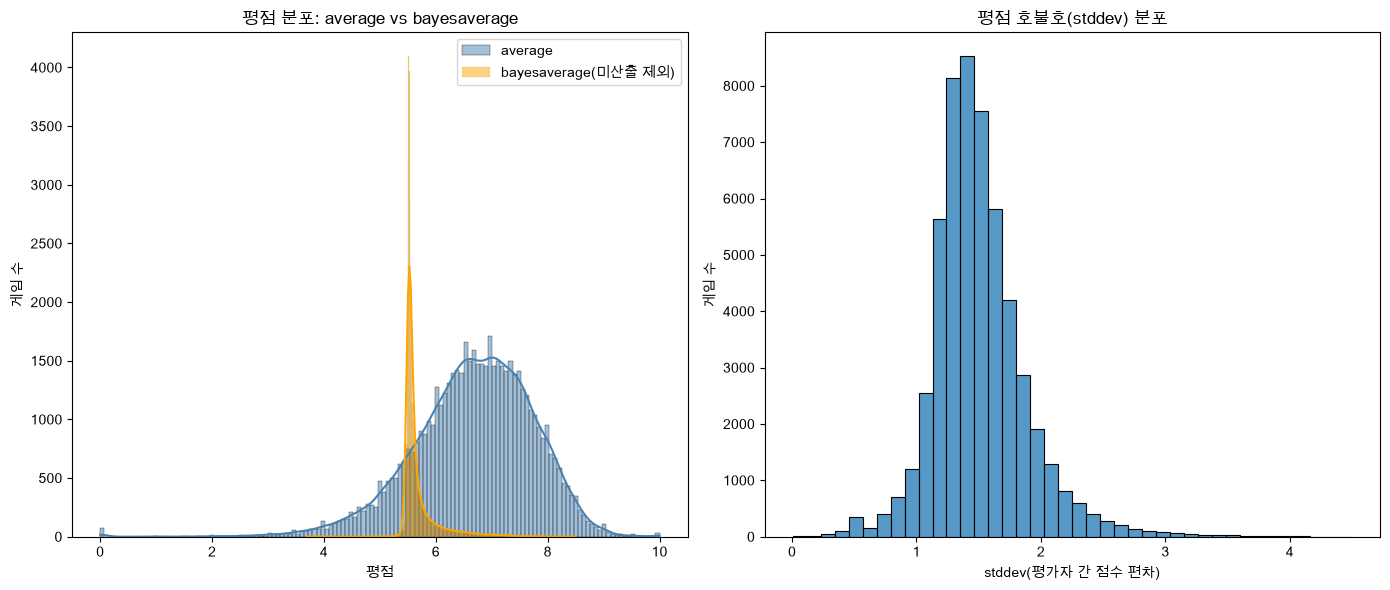

average 평균 6.68 / bayesaverage(미산출 제외) 평균 5.68
stddev(>0) 평균 1.50 / 중앙값 1.46
bayesaverage=0(미산출) 제외 건수: 16,083건


In [ ]:
bayes_valid = item[item["bayesaverage"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=item, x="average", color="steelblue", label="average", kde=True, alpha=0.5, ax=axes[0])
sns.histplot(data=bayes_valid, x="bayesaverage", color="orange", label="bayesaverage(미산출 제외)", kde=True, alpha=0.5, ax=axes[0])
axes[0].set_title("평점 분포: average vs bayesaverage")
axes[0].set_xlabel("평점")
axes[0].set_ylabel("게임 수")
axes[0].legend()

stddev_valid = item[item["stddev"] > 0]["stddev"]
sns.histplot(stddev_valid, bins=40, ax=axes[1])
axes[1].set_title("평점 호불호(stddev) 분포")
axes[1].set_xlabel("stddev(평가자 간 점수 편차)")
axes[1].set_ylabel("게임 수")

plt.tight_layout()
plt.show()

print(f"average 평균 {item['average'].mean():.2f} / bayesaverage(미산출 제외) 평균 {bayes_valid['bayesaverage'].mean():.2f}")
print(f"stddev(>0) 평균 {stddev_valid.mean():.2f} / 중앙값 {stddev_valid.median():.2f}")
print(f"bayesaverage=0(미산출) 제외 건수: {(item['bayesaverage'] == 0).sum():,}건")

**결과**
- `average`(단순 평균) 평균 6.68, `bayesaverage`(베이즈 평균, 미산출 게임 제외) 평균 5.87로 확인, `bayesaverage`가 더 낮음
    - 소수 평가자가 준 극단적으로 후한 점수가 `average`에는 그대로 반영되지만 `bayesaverage`는 보정하기 때문
- `bayesaverage=0`(평가자 30명 미만이라 미산출) 16,083건을 제외하지 않으면 평균이 왜곡되는 것으로 확인
    - 4-2에서 확정한 규칙을 여기서부터 적용
- `stddev`(호불호)는 0 아닌 값 기준 평균 1.50·중앙값 1.46으로 확인
    - 게임들 사이에 큰 차이 없이 대체로 비슷한 수준의 의견 일치도


<a id="sec-6-2"></a>
### 6-2. 전체 수치형 변수 상관관계 히트맵

- 복잡도-평점 하나만 보지 않고, 게임의 주요 수치형 변수를 전부 스피어만 상관(순위 기반 상관계수 — [2-3](#sec-2-3)에서 확인했듯 데이터가 정규분포가 아니라서 이 방법을 쓴다. 
- 값은 -1~1이고 0이면 관계 없음)으로 계산해 한 번에 훑는다. `averageweight`/`minage`/`stddev`는 0을 결측으로 마스킹([2-2](#sec-2-2)에서 확립한 규칙)한 뒤 계산한다.

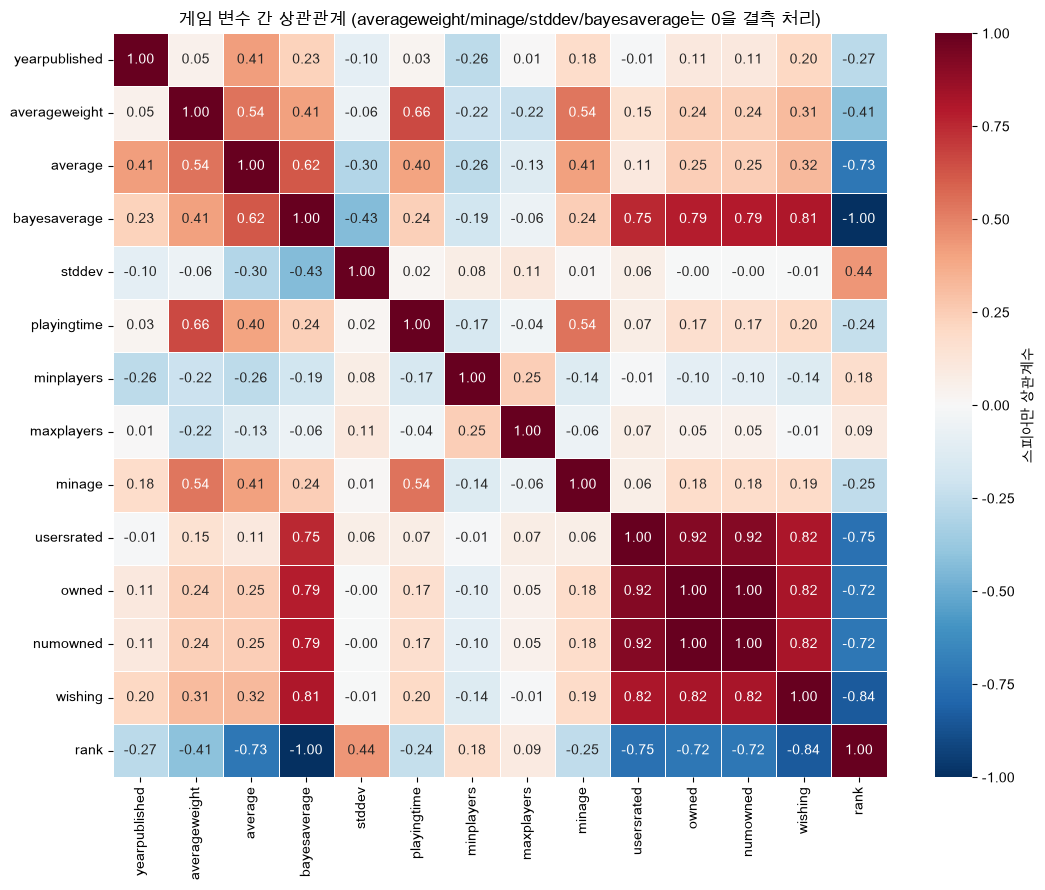

In [ ]:
corr_cols = ["yearpublished", "averageweight", "average", "bayesaverage", "stddev",
             "playingtime", "minplayers", "maxplayers", "minage",
             "usersrated", "owned", "numowned", "wishing", "rank"]
corr_df = item_wide[corr_cols].copy()
for c in ["averageweight", "minage", "stddev", "bayesaverage"]:
    corr_df[c] = corr_df[c].replace(0, np.nan)

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "스피어만 상관계수"})
plt.title("게임 변수 간 상관관계 (averageweight/minage/stddev/bayesaverage는 0을 결측 처리)")
plt.tight_layout()
plt.show()

**결과**
- 정의상 같은 값이라 의미 없는 관계 2개 확인: `numowned`↔`owned` 상관 1.00(같은 값의 다른 이름), `bayesaverage`↔`rank` -1.00(BGG가 애초에 `bayesaverage` 순서로 순위를 매기므로 원인이 아니라 정의)
- 상식과 일치해 예상대로 확인된 관계: `averageweight`(복잡도)↔`playingtime` 0.66, `averageweight`↔`minage`(권장 연령) 0.54
    - "무거운 게임일수록 오래 걸리고 어린이용이 아니다"라는 당연한 상식과 일치
- 결측 마커가 관계를 부풀리고 있던 사례 확인: `usersrated`↔`bayesaverage` 0을 포함하면 0.91, 미산출 게임 제외 시 0.75로 확인, `owned`↔`bayesaverage` 0.86→0.79로 확인
    - 인기 지표들이 서로 강하게 묶인다는 결론은 유지되지만, 크기는 미산출 게임이 섞여 과장돼 있었음
- 미리 예상하기 어려웠던 지점 확인: `yearpublished`↔`average` 0.41(최근 게임일수록 평점이 높음), `stddev`↔`average` -0.30(평점이 높은 게임일수록 의견이 덜 갈림)
    - 최신 편향 때문인지 실제 품질 향상인지는 이 데이터만으로 알 수 없다


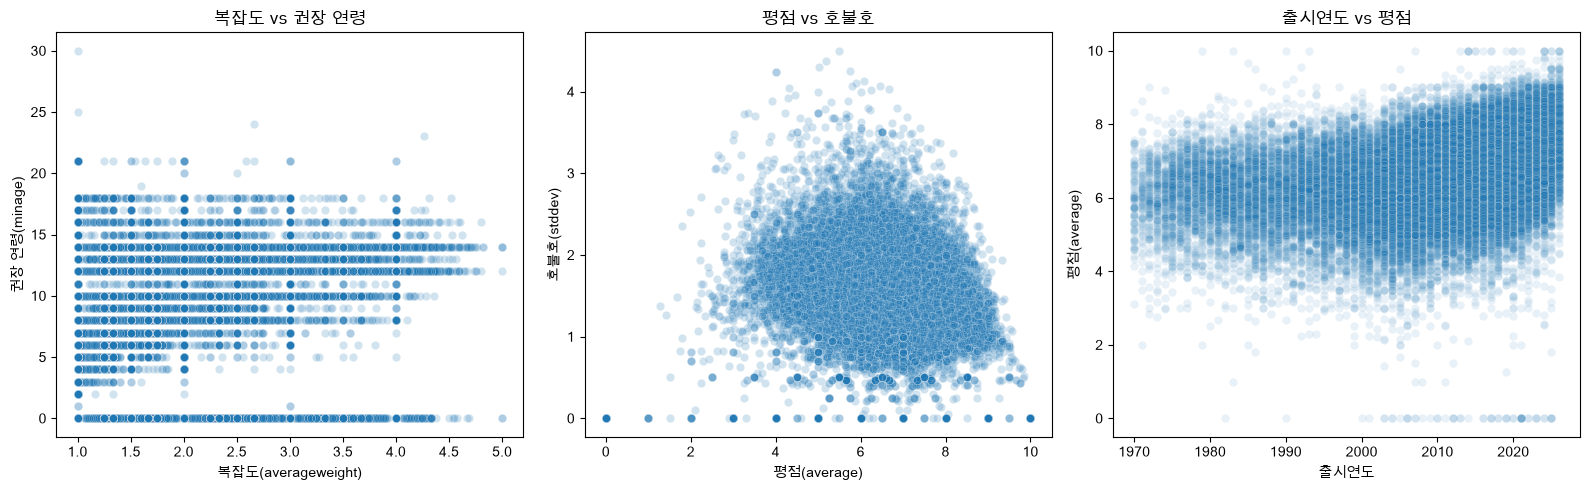

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=item, x="averageweight", y="minage", alpha=0.2, ax=axes[0])
axes[0].set_title("복잡도 vs 권장 연령")
axes[0].set_xlabel("복잡도(averageweight)")
axes[0].set_ylabel("권장 연령(minage)")

sns.scatterplot(data=item, x="average", y="stddev", alpha=0.2, ax=axes[1])
axes[1].set_title("평점 vs 호불호")
axes[1].set_xlabel("평점(average)")
axes[1].set_ylabel("호불호(stddev)")

plot_df = item[(item["yearpublished"] >= 1970) & (item["yearpublished"] <= 2026)]
sns.scatterplot(data=plot_df, x="yearpublished", y="average", alpha=0.1, ax=axes[2])
axes[2].set_title("출시연도 vs 평점")
axes[2].set_xlabel("출시연도")
axes[2].set_ylabel("평점(average)")

plt.tight_layout()
plt.show()

**결과**
- 복잡도-권장연령 산점도는 우상향 경향이 뚜렷한 것으로 확인
    - 앞서 확인한 "무거운 게임=높은 권장연령" 예상과 일치
- 평점-호불호 산점도는 평점이 높아질수록 점들이 아래로 모이는 경향으로 확인
    - 미리 예상하기 어려웠던 관계가 시각적으로도 확인됨
- 출시연도-평점 산점도는 넓게 퍼져 있지만 최근으로 갈수록 조금씩 높아지는 완만한 우상향으로 확인


<a id="sec-6-3"></a>
### 6-3. 유저 개인의 평가 성향

- 개인이 매긴 `user_rating`과 그 게임의 평균 평점(`bayesaverage`)을 게임 단위로 이어붙여 차이를 본다
- 이 유저들이 평균적으로 후하게 주는지 박하게 주는지, 그리고 개인별로 이 성향이 얼마나 일관적인지 확인한다.

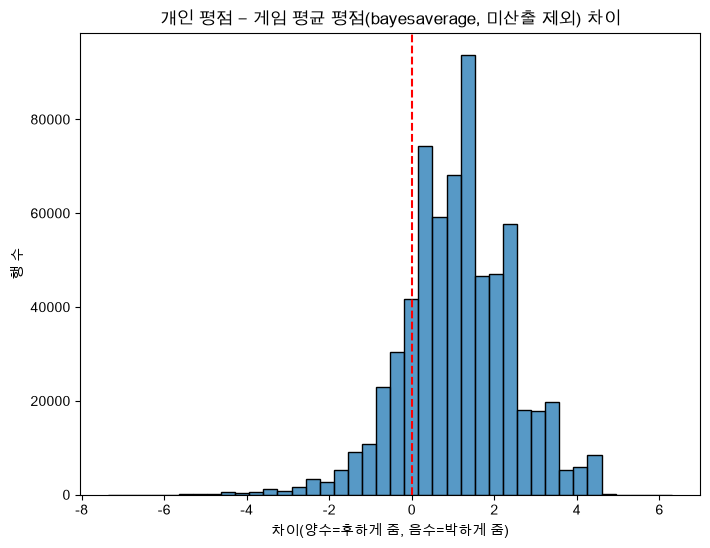

평균 차이: +1.13
중앙값: +1.15
유저별 평균 편차의 표준편차: 0.79 (유저마다 성향이 얼마나 다른지)


In [ ]:
rated_pairs = user_item[user_item["user_rating"].notna()].merge(
    item_wide[item_wide["bayesaverage"] > 0][["objectid", "bayesaverage"]], on="objectid", how="inner"
)
rated_pairs["rating_diff"] = rated_pairs["user_rating"] - rated_pairs["bayesaverage"]

plt.figure(figsize=(8, 6))
sns.histplot(rated_pairs["rating_diff"], bins=40)
plt.axvline(0, color="red", linestyle="--")
plt.title("개인 평점 − 게임 평균 평점(bayesaverage, 미산출 제외) 차이")
plt.xlabel("차이(양수=후하게 줌, 음수=박하게 줌)")
plt.ylabel("행 수")
plt.show()

print(f"평균 차이: {rated_pairs['rating_diff'].mean():+.2f}")
print(f"중앙값: {rated_pairs['rating_diff'].median():+.2f}")

user_bias = rated_pairs.groupby("user_id")["rating_diff"].mean()
print(f"유저별 평균 편차의 표준편차: {user_bias.std():.2f} (유저마다 성향이 얼마나 다른지)")

**결과**
- 평균 차이 +1.13, 중앙값 +1.15로 확인
    - 유저들은 전반적으로 게임의 평균 평점(`bayesaverage`)보다 후하게 평점을 주는 것으로 나타남
    - `bayesaverage=0`(미산출) 게임을 제외하지 않으면 이 차이가 +1.39로 부풀려지는 것으로 확인
        - 미산출 게임에도 유저는 평점을 남기지만 비교 대상인 `bayesaverage`가 0이라 차이가 실제보다 크게 계산됐기 때문
    - 보유한 게임에만 평점을 남기는 경향과 맞물린 결과로 판단
- 유저별 평균 편차의 표준편차는 0.79로 확인
    - 유저마다 후하고 박한 정도가 꽤 다르다는 것을 시사
- [Segment 분석](03.Segment_Wishlist.ipynb)에서 이 개인차를 유저 유형과 연결해본다


<a id="sec-6-4"></a>
### 6-4. 복잡도와 평점

- 6-2가 전체 상관관계 그림이라면, 여기서는 그중 하나(복잡도-평점 관계)를 자세히 뜯어본다. 
- 그 전에 먼저 평점 지표부터 고른다: `average` 상위 = 진짜 명작인가, 소수 만점 평가인가?

In [ ]:
cols = ['name', 'average', 'bayesaverage', 'usersrated']
display(item.nlargest(10, 'average')[cols])
display(item.nlargest(10, 'bayesaverage')[cols])

,name,average,bayesaverage,usersrated
47298,"Catan: Mowlin, the Benevolent Ram",10.0,0.0,1
47541,Ascensor of Braga,10.0,0.0,1
47857,Game of Puss in Boots,10.0,0.0,1
51267,Las Ovejas y el Dragón,10.0,0.0,1
52392,Pizza King,10.0,0.0,2
52489,Rocket Ranchers: Even MORE Space Cats!,10.0,0.0,1
52705,Top Cat: The Santa Claws Scam,10.0,0.0,1
55810,Uh-Oh Mountain,10.0,0.0,1
58076,1001 Tuesday Knights,10.0,0.0,1
59537,Rocket Ranchers (2nd Edition),10.0,0.0,2


,name,average,bayesaverage,usersrated
11778,The Castles of Burgundy: Special Edition,9.14091,8.49356,12073
15356,Terraforming Mars: Prelude,8.84803,8.41368,17850
11110,Brass: Birmingham,8.56007,8.39033,59792
11926,Ark Nova,8.53710,8.35302,62616
8739,Pandemic Legacy: Season 1,8.50119,8.34418,57722
11055,Gloomhaven,8.53360,8.29134,67592
19158,Dune: Imperium – Uprising,8.69946,8.25707,19850
11182,Dune: Imperium,8.40677,8.21893,59493
19616,Twilight Imperium: Fourth Edition,8.55979,8.21770,28895
18892,Spirit Island: Jagged Earth,9.32653,8.20702,6388


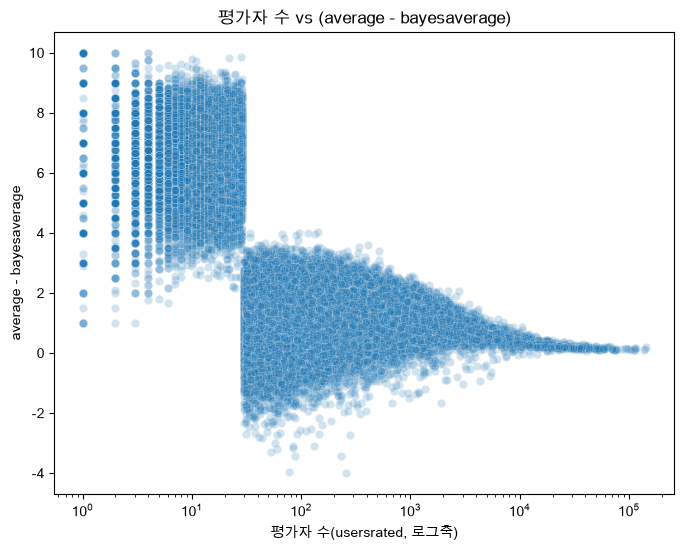

In [ ]:
item['rating_gap'] = item['average'] - item['bayesaverage']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=item, x='usersrated', y='rating_gap', alpha=0.2)
plt.xscale('log')
plt.title("평가자 수 vs (average - bayesaverage)")
plt.xlabel("평가자 수(usersrated, 로그축)")
plt.ylabel("average - bayesaverage")
plt.show()

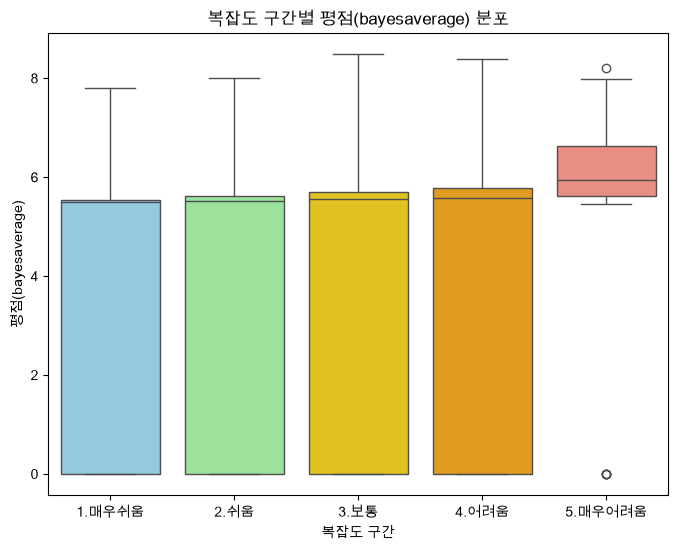

,column,method,correlation,p_value,abs_corr,significant
0,averageweight,spearman,0.2816,0.0,0.2816,True


In [ ]:
bins = [0, 1.5, 2.5, 3.5, 4.5, 5]
labels = ['1.매우쉬움', '2.쉬움', '3.보통', '4.어려움', '5.매우어려움']
item['complexity_bucket'] = pd.cut(item['averageweight'], bins=bins, labels=labels)
palette = ['skyblue', 'lightgreen', 'gold', 'orange', 'salmon']

plt.figure(figsize=(8, 6))
sns.boxplot(data=item, x='complexity_bucket', y='bayesaverage', palette=palette, legend=False)
plt.title("복잡도 구간별 평점(bayesaverage) 분포")
plt.xlabel("복잡도 구간")
plt.ylabel("평점(bayesaverage)")
plt.show()
AdvanceEDA.check_correlation(item[['averageweight', 'bayesaverage']], target='bayesaverage', method='spearman')

In [ ]:
# bayesaverage=0(미산출) 제외 후 복잡도-평점 상관 재계산
item_bv = item[item['bayesaverage'] > 0]
print("bayesaverage 미산출 제외 후:")
display(AdvanceEDA.check_correlation(item_bv[['averageweight', 'bayesaverage']], target='bayesaverage', method='spearman'))

# 교란 점검: 복잡도 높은 게임은 애초에 매니아만 평가할 수 있음 — 평가자 수로 층화해도 관계가 유지되는지 확인
heavy_rated = item_bv[item_bv['usersrated'] >= item_bv['usersrated'].median()]
print("평가자 수 median 이상으로 층화(미산출 제외 기준):")
AdvanceEDA.check_correlation(heavy_rated[['averageweight', 'bayesaverage']], target='bayesaverage', method='spearman')

bayesaverage 미산출 제외 후:


,column,method,correlation,p_value,abs_corr,significant
0,averageweight,spearman,0.4073,0.0,0.4073,True


평가자 수 median 이상으로 층화(미산출 제외 기준):


,column,method,correlation,p_value,abs_corr,significant
0,averageweight,spearman,0.3965,0.0,0.3965,True


**결과**
- `average` 상위 10개는 대부분 평가자 수가 적은 게임으로 확인
- 소수 팬의 만점 몰림 가능성을 시사, `bayesaverage`는 이 쏠림을 보정한 지표라 이후 "평점"은 `bayesaverage`를 기준으로 사용

**복잡도와 평점의 관계**
- 통설(어려울수록 평점이 높다)과 방향은 일치하지만 강도는 약한 것으로 확인
    - `bayesaverage=0`(미산출)을 포함하면 스피어만 상관 0.28, 제외하면 0.41로 커짐
    - "관계가 약하다"는 인상 자체가 상당 부분 미산출 게임 혼입 때문이었다는 것을 시사
- 교란 점검(미산출 제외 후 평가자 수 median 이상으로 층화) 결과 상관 0.40으로 층화 전후 거의 그대로인 것으로 확인
    - "평가자 수로 층화하니 관계가 커졌다"가 아니라, 애초에 미산출 게임이 관계를 희석시키고 있었다는 설명이 맞음
- 여전히 "복잡도가 평점을 결정한다"고 단정할 만큼 강한 관계는 아니라는 것을 시사
- 이 관계는 9-3에서 "복잡도가 플레이 전환에도 영향이 있는가"로 이어간다


**결과**
- 복잡도(`averageweight`)와 플레이타임(`playingtime`)은 무거운 게임일수록 오래 걸리는 당연한 관계로 확인, 별도 다중공선성 이슈는 아님


<a id="sec-7"></a>
## 7. BGG 게임 카탈로그의 확장 추이

- [2-2](#sec-2-2): 극단적 과거값 = 결측 마커 다수, 실제 고대게임은 소수
- 이건 실제 시장 매출·규모가 아니라 **BGG에 등록된 게임 수의 추이**다. [Trend 분석](04.Trend.ipynb) 컷오프를 여기서 정한다.

In [ ]:
bins = [-float('inf'), 1899, 1999, float('inf')]
labels = ['1900년 미만', '1900년대 (1900~1999)', '2000년대 이후 (2000~)']

year_group_ratio = (
    pd.cut(item_wide['yearpublished'], bins=bins, labels=labels)
    .value_counts(normalize=True) * 100
).round(2).reset_index(name='percentage')

year_group_ratio

,yearpublished,percentage
0,2000년대 이후 (2000~),84.05
1,1900년대 (1900~1999),14.13
2,1900년 미만,1.82


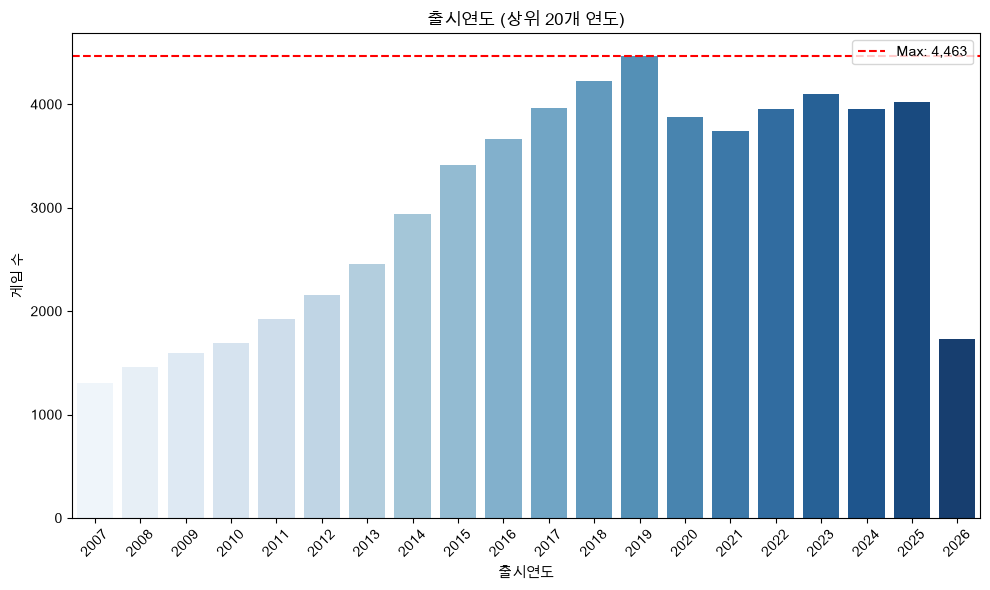

In [ ]:
yearpublished_cnt = item_wide['yearpublished'].value_counts().reset_index(name='count')
yearpublished_cnt.sort_values(by=['count'], ascending=False, inplace=True)
top20_years = yearpublished_cnt.head(20).sort_values(by=['yearpublished'], ascending=True)
top20_years['yearpublished'] = top20_years['yearpublished'].astype(int).astype(str)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top20_years, x='yearpublished', y='count', palette='Blues')
max_val = top20_years['count'].max()

plt.axhline(y=max_val, color='red', linestyle='--', linewidth=1.5, label=f'Max: {max_val:,}')

plt.title('출시연도 (상위 20개 연도)')
plt.xlabel('출시연도')
plt.ylabel('게임 수')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**결과**
- 게임의 84.05%가 2000년대 이후 출시, 14.13%가 1900년대, 1.82%가 1900년 미만인 것으로 확인
    - 1900년 미만 중 82.2%(1,198개)는 실제 고대 게임이 아니라 `yearpublished=0` 결측
- 발매연도 반대쪽 끝에는 발매예정작 113건(2027년 112개, 2030년 1개)도 확인
- 트렌드 분석 컷오프는 2000년으로 잡는다
    - 2000년 이후가 전체의 84.05%로 압도적이고, 그 이전 구간은 표본이 적어 연도별 비율이 불안정하기 때문
- 이 추이는 실제 시장 성장이 아니라 BGG 카탈로그에 등록된 게임 수의 확장 추이라는 점에 유의(매출·판매량 데이터는 이 프로젝트 범위 밖)
- [Trend 분석](04.Trend.ipynb)에서 이 컷오프를 그대로 사용한다


<a id="sec-8"></a>
## 8. 이 데이터로 퍼널을 만들 수 있는가

02에서 쓸 퍼널을 여기서 미리 검증한다. 그 전에 먼저, 퍼널의 핵심 값인 `numplays`가 정확히 무엇을 재는지부터 확인한다.

<a id="sec-8-0"></a>
### 8-0. `numplays`는 무엇을 재는 값인가

`numplays`는 유저가 BGG에 직접 입력한 누적 플레이 횟수다. "실제로 안 했다"와 "기록을 안 했다"가 섞여 있을 수 있는데, 마침 이걸 검증할 수단이 있다 — 개별 플레이 로그를 직접 수집한 `user_play`(730명, 1-6)와 교차하면 된다.

In [ ]:
play_users = set(user_play_raw["user_id"].unique())
play_pairs = user_play_raw.groupby(["user_id", "objectid"]).size().rename("n_logs").reset_index()

check = user_item[user_item["user_id"].isin(play_users)].merge(play_pairs, on=["user_id", "objectid"], how="left")
check["n_logs"] = check["n_logs"].fillna(0)

a = ((check["numplays"] == 0) & (check["n_logs"] > 0)).sum()
b = ((check["numplays"] > 0) & (check["n_logs"] == 0)).sum()
n_zero = (check["numplays"] == 0).sum()
n_pos = (check["numplays"] > 0).sum()

print(f"[730명, 소유 행 {len(check):,}건 기준]")
print(f"numplays>0인데 실제 플레이 로그 없음: {b:,}건 ({b/n_pos:.2%} of numplays>0 {n_pos:,}건)")
print(f"numplays=0인데 실제 플레이 로그 있음: {a:,}건 ({a/n_zero:.2%} of numplays=0 {n_zero:,}건)")

no_log_users = set(pd.read_csv(DATA_DIR / "plays_sample_users.csv").iloc[:, 0]) - play_users
print(f"\nplays 대상 중 플레이 로그를 한 건도 남기지 않은 유저: {len(no_log_users):,}명")

[730명, 소유 행 390,686건 기준]
numplays>0인데 실제 플레이 로그 없음: 0건 (0.00% of numplays>0 129,348건)
numplays=0인데 실제 플레이 로그 있음: 1,289건 (0.49% of numplays=0 261,338건)

plays 대상 중 플레이 로그를 한 건도 남기지 않은 유저: 335명


**결과**
- 양방향 모두 어긋나는 비율이 1% 미만으로 확인
    - `numplays`는 BGG 플레이 로그와 사실상 동일한 소스라는 뜻
- `numplays=0`은 정확히는 "BGG에 기록을 안 남겼다"는 의미이지 "안 했다"와 완전히 같은 말은 아니지만, 그 차이가 0.5%도 안 될 만큼 작아 이후부터는 편의상 "안 함"으로 쓴다
- 다만 실제로는 했지만 BGG에 기록을 안 남기는 유저는 이 데이터로 구분할 수 없다는 원천적 한계는 남는다
    - 플레이 대상 유저 중 상당수가 로그를 한 건도 안 남긴다는 사실이 이 한계를 뒷받침


<a id="sec-8-1"></a>
### 8-1. 퍼널 단계 정의

**뺀 것과 그 근거**
- `own=1`로만 수집 → 관심/위시/구매/소유 이전 단계는 측정 불가(생존편향, 배경 참고).
- `user_rating`에 시점이 없어 시간 순서 단계로 쓸 수 없다 — 8-3에서 이걸 데이터로 확인한다.
- `user_wishlist`(1-7)도 같은 이유(등록 시점 없음)로 제외.

**확정 정의 — 퍼널은 3단계, Core User는 별도 세그먼트**

| 구분 | 단계 | 정의 |
|---|---|---|
| 퍼널 | 0. 전체 대상 | `user_info` 3,000명 |
| 퍼널 | 1. 보유 게임 있음 | dedup된 `user_item`에 1행 이상 |
| 퍼널 | 2. 플레이함 | `SUM(numplays) > 0` |
| 퍼널 | 3. 반복 플레이 | `numplays ≥ 2`인 소유 게임 1개 이상 |
| **세그먼트**(퍼널 아님) | Core User | 2단계 통과자 중 `SUM(numplays)` 상위 20%(분위수 컷오프) |

- **3단계 주석**: "게임 1개라도 2회 이상"은 가장 느슨한 기준이다. 더 엄격한 대안(플레이한 게임 절반 이상 반복, 총 플레이 10회 이상)도 있지만, 느슨한 기준에서도 감소가 6.9%p뿐이라는 사실 자체가 결론이라 이 정의를 쓴다. 시점 정보가 없으므로 **"반복 플레이"까지만 말하고 "지속 참여"·"리텐션"이라 부르지 않는다**. 시간적 지속성은 [Trend 분석](04.Trend.ipynb)에서 `user_play`로 따로 본다.
- **Core User 주석**: 퍼널 단계가 **아니다.** 통과 실패가 일어나는 관문이 아니라 플레이어를 활동량으로 자른 분류선이다. 컷오프는 데이터가 갱신되면 함께 움직이며, 고정된 기준이 아니다.

In [ ]:
N = len(user_info)
u_owned = user_item["user_id"].nunique()

by_user = user_item.groupby("user_id").agg(
    total_numplays=("numplays", "sum"),
    n_owned=("objectid", "size"),
    n_repeat=("numplays", lambda s: (s >= 2).sum()),
    n_rated=("user_rating", lambda s: s.notna().sum()),
)
players = by_user[by_user["total_numplays"] > 0]
repeat_players = players[players["n_repeat"] > 0]
core_cutoff = players["total_numplays"].quantile(0.8)
core_users = players[players["total_numplays"] >= core_cutoff]

funnel = pd.DataFrame([
    ["0.전체 대상", N, None],
    ["1.컬렉션 보유", u_owned, u_owned / N],
    ["2.플레이함", len(players), len(players) / u_owned],
    ["3.반복 플레이", len(repeat_players), len(repeat_players) / len(players)],
], columns=["단계", "인원", "직전 대비"])
funnel["전체 대비"] = funnel["인원"] / N
display(funnel)
print(f"\nCore User(세그먼트, 컷오프={core_cutoff:.0f}회): {len(core_users):,}명 (플레이어 중 {len(core_users)/len(players):.1%})")
print(f"가장 큰 관측상 감소 구간: 1→2단계, {u_owned - len(players):,}명 감소")

,단계,인원,직전 대비,전체 대비
0,0.전체 대상,3000,NaN,1.000000
1,1.컬렉션 보유,2944,0.981333,0.981333
2,2.플레이함,1988,0.675272,0.662667
3,3.반복 플레이,1850,0.930584,0.616667



Core User(세그먼트, 컷오프=2157회): 398명 (플레이어 중 20.0%)
가장 큰 관측상 감소 구간: 1→2단계, 956명 감소


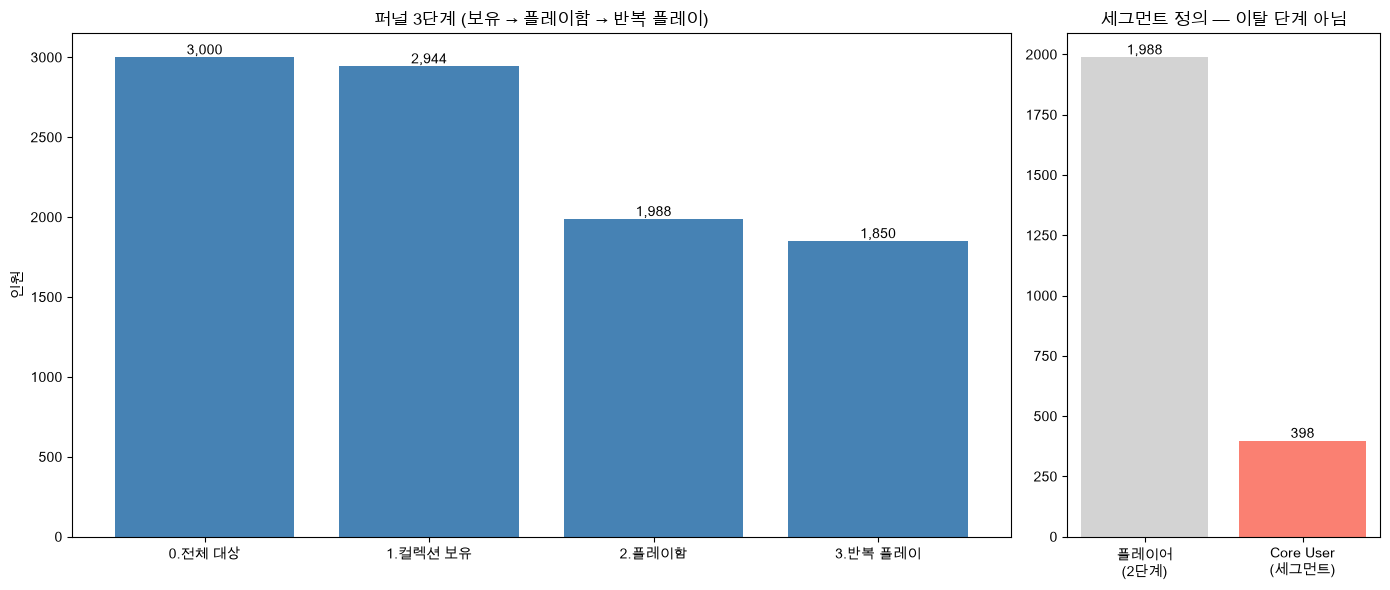

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})

axes[0].bar(funnel["단계"], funnel["인원"], color="steelblue")
axes[0].set_title("퍼널 3단계 (보유 → 플레이함 → 반복 플레이)")
axes[0].set_ylabel("인원")
for i, v in enumerate(funnel["인원"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(["플레이어\n(2단계)", "Core User\n(세그먼트)"], [len(players), len(core_users)], color=["lightgray", "salmon"])
axes[1].set_title("세그먼트 정의 — 이탈 단계 아님")
for i, v in enumerate([len(players), len(core_users)]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**결과**
- 전체 흐름은 3,000명 → 2,944명(98.1%) → 1,988명(67.5%) → 1,850명(93.1%)으로 확인
- 가장 큰 감소 구간은 "보유 → 플레이함"으로 확인(-32.5%p, 956명)
    - 이 구간을 넘은 유저는 93.1%가 반복 플레이까지 이어짐
- 이 감소가 "안 해서"인지 "해놓고 기록만 안 남겨서"인지는 8-0의 한계상 구분할 수 없다는 것을 시사
- 그렇기 때문에 가장 큰 감소 구간인 "보유 → 플레이함"을 [Funnel 분석](02.Funnel_Retention.ipynb)의 우선 분석 대상으로 삼는다
- Core User(398명)는 이 감소 구간과 별개의 세그먼트로 확인
    - 21.5%라는 숫자는 활동을 그만뒀다는 의미가 아니라 분위수 컷오프(2,157회 이상)로 정의된 결과


<a id="sec-8-3"></a>
### 8-3. 평가 참여율은 퍼널 단계가 아니다

`user_rating`을 퍼널 앞단(예: "소유→평가→플레이")에 넣지 않은 이유를 데이터로 확인한다. 평가 참여율(소유 게임 중 평점을 남긴 비율)이 높을수록 플레이도 많이 한다면 순서가 있는 단계로 볼 여지가 있지만, 실제로는 그렇지 않다.

,n,플레이비율
rate_q,,
1,589,0.743633
2,589,0.796265
3,593,0.731872
4,586,0.689420
5,587,0.413969


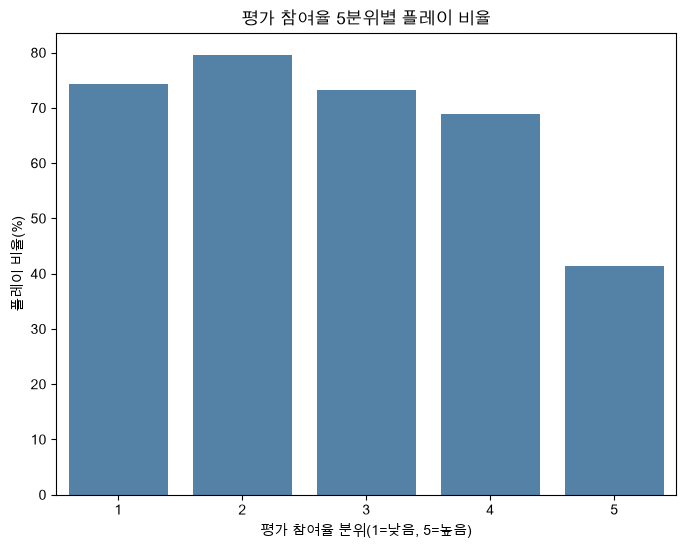

In [ ]:
by_user["rate_ratio"] = by_user["n_rated"] / by_user["n_owned"]
by_user["is_player"] = by_user["total_numplays"] > 0
by_user["rate_q"] = pd.qcut(by_user["rate_ratio"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop")

rate_conv = by_user.groupby("rate_q", observed=True).agg(n=("is_player", "size"), 플레이비율=("is_player", "mean"))
display(rate_conv)

plt.figure(figsize=(8, 6))
sns.barplot(x=rate_conv.index.astype(str), y=rate_conv["플레이비율"] * 100, color="steelblue")
plt.title("평가 참여율 5분위별 플레이 비율")
plt.xlabel("평가 참여율 분위(1=낮음, 5=높음)")
plt.ylabel("플레이 비율(%)")
plt.show()

**결과**
- 평가 참여율 5분위별 플레이 비율은 74.4% → 79.6% → 73.2% → 68.9% → 41.4%로 확인
    - 참여율이 가장 높은 분위에서 오히려 플레이 비율이 가장 낮은, 비단조 패턴으로 나타남
- 평가를 많이 남기는 유저가 플레이도 많이 하는 것은 아니라는 것을 시사
- 그렇기 때문에 평가 참여는 퍼널의 순차 단계가 아니라 별개의 참여(engagement) 축으로 분리해, 11(핵심 지표)에서 보조지표로 다룬다


<a id="sec-9"></a>
## 9. 퍼널 전환을 가르는 후보 변수

8-2에서 확인한 가장 큰 관측상 감소 구간("보유 → 플레이함")을 가르는 후보 변수를 찾는다. 아래 "플레이 비율"은 전부 8-0에서 확인한 정의 그대로다 — **관계가 관측된다는 것 이상은 말하지 않는다.**

<a id="sec-9-1"></a>
### 9-1. 보유 게임 수

,n,비율,중앙값
size_q,,,
1,591,0.373942,35.0
2,590,0.627119,124.0
3,586,0.721843,242.5
4,588,0.816327,452.0
5,589,0.838710,1046.0


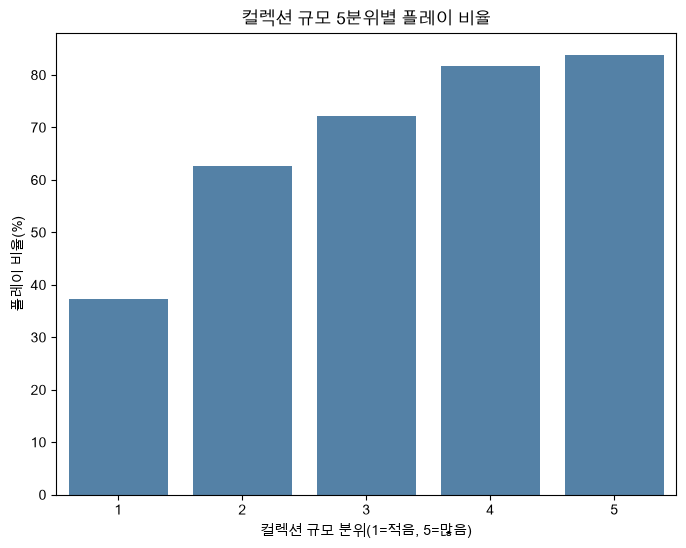

In [ ]:
by_user["size_q"] = pd.qcut(by_user["n_owned"], 5, labels=[1, 2, 3, 4, 5])
size_conv = by_user.groupby("size_q", observed=True).agg(n=("is_player", "size"), 비율=("is_player", "mean"), 중앙값=("n_owned", "median"))
display(size_conv)

plt.figure(figsize=(8, 6))
sns.barplot(x=size_conv.index.astype(str), y=size_conv["비율"] * 100, color="steelblue")
plt.title("컬렉션 규모 5분위별 플레이 비율")
plt.xlabel("컬렉션 규모 분위(1=적음, 5=많음)")
plt.ylabel("플레이 비율(%)")
plt.show()

**결과**
- 보유 게임 수(분위) 구간별 플레이 전환율은 37.4% → 62.7% → 72.2% → 81.6% → 83.9%로 확인
    - 지금까지 살펴본 후보 변수 중 플레이 전환율과 가장 강한 관계
- 다만 보유 게임이 많을수록 그중 하나라도 `numplays > 0`이 될 확률이 자동으로 올라가는 기계적 효과가 섞여 있어, 인과로 해석하지 않는다
    - "보유 게임을 늘리면 플레이한다"는 식으로 읽지 않도록 02에서도 이 관계는 확인만 하고 원인으로 단정하지 않는다


<a id="sec-9-2"></a>
### 9-2. 마지막 로그인 · 가입연도

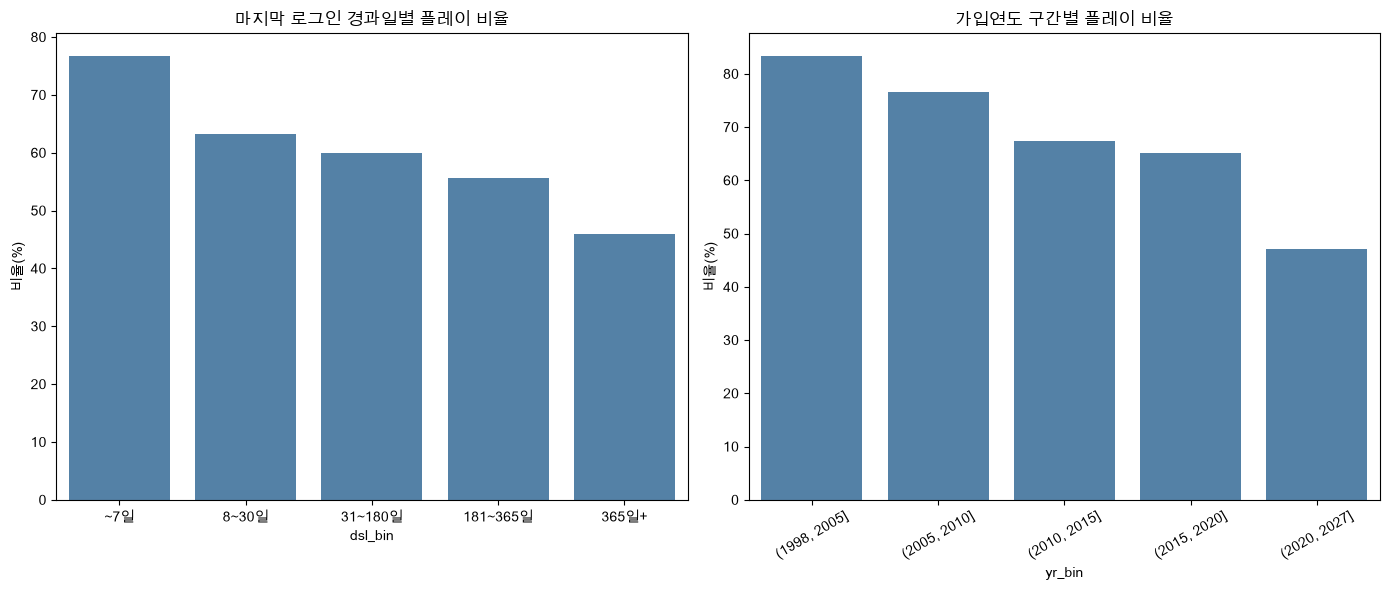

In [ ]:
by_user2 = by_user.merge(user_info.set_index("user_id")[["lastlogin", "yearregistered"]], left_index=True, right_index=True, how="left")
by_user2["days_since_login"] = (pd.Timestamp("2026-09-06") - pd.to_datetime(by_user2["lastlogin"], errors="coerce")).dt.days
by_user2["dsl_bin"] = pd.cut(by_user2["days_since_login"], [-1, 7, 30, 180, 365, 100000],
                              labels=["~7일", "8~30일", "31~180일", "181~365일", "365일+"])
by_user2["yr_bin"] = pd.cut(by_user2["yearregistered"], [1998, 2005, 2010, 2015, 2020, 2027])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
dsl_conv = by_user2.groupby("dsl_bin", observed=True)["is_player"].mean() * 100
sns.barplot(x=dsl_conv.index.astype(str), y=dsl_conv.values, color="steelblue", ax=axes[0])
axes[0].set_title("마지막 로그인 경과일별 플레이 비율")
axes[0].set_ylabel("비율(%)")

yr_conv = by_user2.groupby("yr_bin", observed=True)["is_player"].mean() * 100
sns.barplot(x=yr_conv.index.astype(str), y=yr_conv.values, color="steelblue", ax=axes[1])
axes[1].set_title("가입연도 구간별 플레이 비율")
axes[1].set_ylabel("비율(%)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**결과**
- 마지막 로그인 경과일 구간별 플레이 비율은 75.6% → 63.2% → 60.0% → 55.6% → 45.9%로 확인
    - 관계는 뚜렷하지만 방향이 반대일 수 있어(플레이하는 유저라서 로그인이 잦은 것일 수 있음) 원인 변수가 아니라 현재 활동성을 나타내는 보조 변수로만 쓴다
- 가입연도별로도 83.4%(~2005년 가입)에서 47.1%(2021년~ 가입)까지 차이가 확인
    - 오래 가입한 유저일수록 그동안 플레이할 시간이 많았다는 누적 시간 교란이 섞여 있어, 이 역시 인과로 단정하지 않는다


<a id="sec-9-3"></a>
### 9-3. 게임 복잡도

,n,비율
complexity_bucket,,
~1.5,205745,0.387698
1.5-2,239514,0.314053
2-2.5,259814,0.307197
2.5-3,243836,0.232312
3-3.5,131286,0.257293
3.5+,123542,0.254820


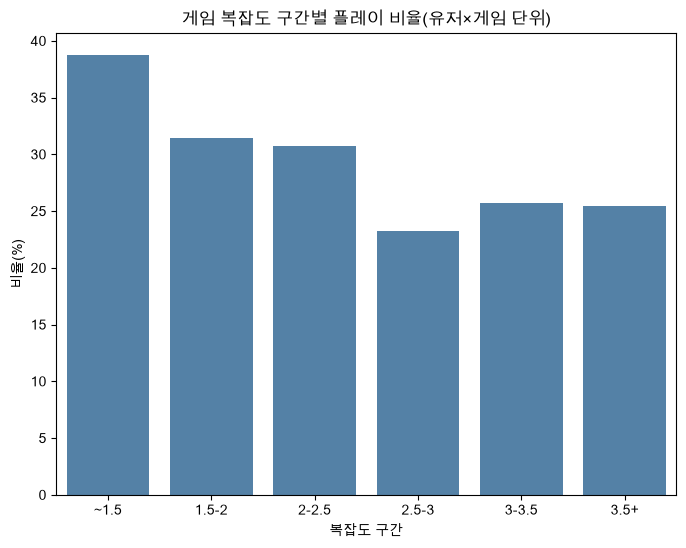

In [ ]:
item_pairs = user_item.merge(item_wide[["objectid", "averageweight"]], on="objectid", how="left")
item_pairs_valid = item_pairs[item_pairs["averageweight"] > 0].copy()
item_pairs_valid["complexity_bucket"] = pd.cut(
    item_pairs_valid["averageweight"], [0, 1.5, 2, 2.5, 3, 3.5, 5],
    labels=["~1.5", "1.5-2", "2-2.5", "2.5-3", "3-3.5", "3.5+"]
)
cx_conv = item_pairs_valid.groupby("complexity_bucket", observed=True).agg(
    n=("numplays", "size"), 비율=("numplays", lambda s: (s > 0).mean())
)
display(cx_conv)

plt.figure(figsize=(8, 6))
sns.barplot(x=cx_conv.index.astype(str), y=cx_conv["비율"] * 100, color="steelblue")
plt.title("게임 복잡도 구간별 플레이 비율(유저×게임 단위)")
plt.xlabel("복잡도 구간")
plt.ylabel("비율(%)")
plt.show()

**결과**
- 복잡도 구간별 플레이 비율은 38.8% → 31.4% → 30.7% → 23.2%(최저) → 25.7% → 25.5%로 확인
    - 단조 감소는 아니지만, 가장 가벼운 구간과 중간 구간 사이에 뚜렷한 차이가 나타남
- 6-4에서 확인한 복잡도-평점 상관(0.41)과는 별개로, 복잡도가 플레이 여부와도 관계가 있다는 것을 시사
    - [Funnel 분석](02.Funnel_Retention.ipynb)·[Segment 분석](03.Segment_Wishlist.ipynb)에서 세그먼트별 복잡도 선호와 함께 살펴본다


<a id="sec-9-4"></a>
### 9-4. 게임 인기도

,n,비율,중앙값
pop_q,,,
1,259291,0.173014,239.0
2,258983,0.204311,1050.0
3,259059,0.259092,2987.0
4,259097,0.319521,7796.0
5,259083,0.448300,31038.0


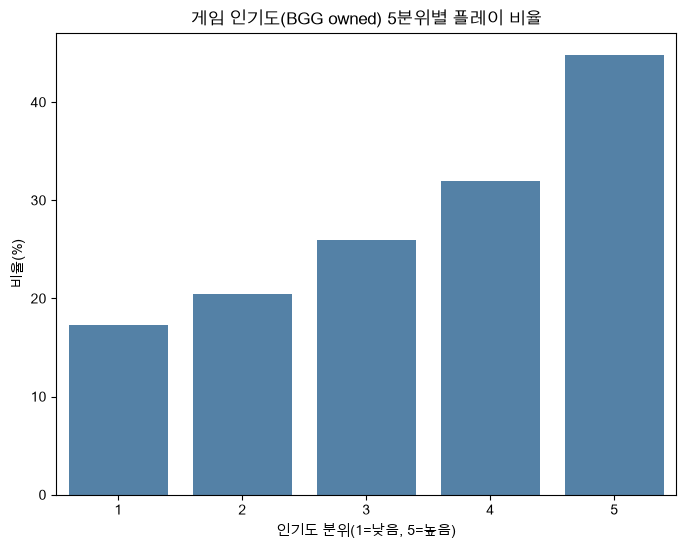

In [ ]:
item_pairs2 = user_item.merge(item_wide[["objectid", "owned"]], on="objectid", how="left")
item_pairs2["pop_q"] = pd.qcut(item_pairs2["owned"], 5, labels=[1, 2, 3, 4, 5], duplicates="drop")
pop_conv = item_pairs2.groupby("pop_q", observed=True).agg(n=("numplays", "size"), 비율=("numplays", lambda s: (s > 0).mean()), 중앙값=("owned", "median"))
display(pop_conv)

plt.figure(figsize=(8, 6))
sns.barplot(x=pop_conv.index.astype(str), y=pop_conv["비율"] * 100, color="steelblue")
plt.title("게임 인기도(BGG owned) 5분위별 플레이 비율")
plt.xlabel("인기도 분위(1=낮음, 5=높음)")
plt.ylabel("비율(%)")
plt.show()

**결과**
- 인기도(usersrated) 구간별 플레이 비율은 17.3% → 20.4% → 25.9% → 32.0% → 44.8%로 단조 증가하는 것으로 확인
- 잘 알려진 게임일수록 소유자 중 실제로 플레이하는 비율도 높다는 관계가 뚜렷하게 나타남


<a id="sec-9-5"></a>
### 9-5. 게임 출시연도

In [ ]:
item_pairs3 = user_item.merge(item_wide[["objectid", "yearpublished"]], on="objectid", how="left")
item_pairs3 = item_pairs3[item_pairs3["yearpublished"] > 1980].copy()
item_pairs3["yb"] = pd.cut(item_pairs3["yearpublished"], [1980, 2000, 2010, 2015, 2020, 2027])
yr_conv2 = item_pairs3.groupby("yb", observed=True).agg(n=("numplays", "size"), 비율=("numplays", lambda s: (s > 0).mean()))
yr_conv2

,n,비율
yb,,
"(1980, 2000]",106824,0.256103
"(2000, 2010]",209184,0.316678
"(2010, 2015]",265676,0.278851
"(2015, 2020]",377564,0.277341
"(2020, 2027]",292620,0.277855


**결과**
- 출시연도 구간별 플레이 비율은 25.6%~31.7%로 구간 간 차이가 미미한 것으로 확인
- 출시연도 자체는 플레이 여부를 가르는 변수가 아니라는 것을 시사, 후보에서 제외한다


<a id="sec-9-6"></a>
### 9-6. 위시 비율과 미플레이 비율

원하는 것(위시리스트)과 실제 기록(플레이)이 다른지 본다. `wish_ratio`는 BGG 전체 집계, 아래 새로 정의하는 지표는 우리가 수집한 2,944명 기준 — **분모가 다른 두 지표의 관계**라는 점을 먼저 밝힌다.

In [ ]:
wish_owned

,objectid,name,yearpublished,averageweight,owned,wishing,n_sample_owners,n_sample_unplayed
0,43443,Castle Panic,2009,1.6565,31270,2764,246,117
1,371947,3 Ring Circus,2023,2.7581,6692,1073,119,66
2,406174,Kinfire Delve: Callous' Lab,2024,2.2121,5876,1015,79,59
3,54043,Jaipur,2009,1.4625,97198,8818,749,331
4,427131,Scholars of the South Tigris: Body of Books,2025,4.0000,1679,185,55,50
...,...,...,...,...,...,...,...,...
80122,163920,Gaïa,2014,1.9344,2945,265,37,25
80123,174837,Sol: Last Days of a Star,2017,2.8889,2793,1529,53,25
80124,138104,Warmachine: High Command,2013,2.3438,1955,110,37,25
80125,13071,Age of Gods,2004,2.3049,1369,116,34,25


**두 개의 축 — BGG 전체 집계 vs 우리가 수집한 데이터**
- `owned`/`wishing`: BGG 전체 집계
- `n_sample_owners`/`n_sample_unplayed`: 우리가 수집한 데이터 기준 집계(단, `wish_owned`는 dedup 전 `stg_user_item` 기준 SQL 집계 — `n_sample_unplayed`는 "안 한 사람 수"로 읽는다, 8-0 참고)

In [ ]:
print(f"wish_owned: {len(wish_owned):,}개 게임")
wish_owned[['owned', 'wishing', 'n_sample_owners', 'n_sample_unplayed']].describe()

wish_owned: 80,127개 게임


,owned,wishing,n_sample_owners,n_sample_unplayed
count,80127.000000,80127.000000,80127.000000,80127.000000
mean,966.996855,127.644627,16.341233,11.740387
std,4512.498559,626.974148,42.639144,25.671175
min,0.000000,0.000000,1.000000,0.000000
25%,42.000000,5.000000,1.000000,1.000000
50%,143.000000,16.000000,4.000000,3.000000
75%,517.000000,59.000000,13.000000,11.000000
max,243779.000000,27385.000000,1230.000000,590.000000


**"다들 갖고 싶어만 하는 게임" 위시 비율**
- 위시 비율 = 위시리스트에 담은 사람 수 / (소유자 수 + 위시리스트에 담은 사람 수).
- 소유자 대비 위시리스트에 담은 사람이 얼마나 많은지 나타낸다. 이 비율이 높은 게임의 공통 특성은?

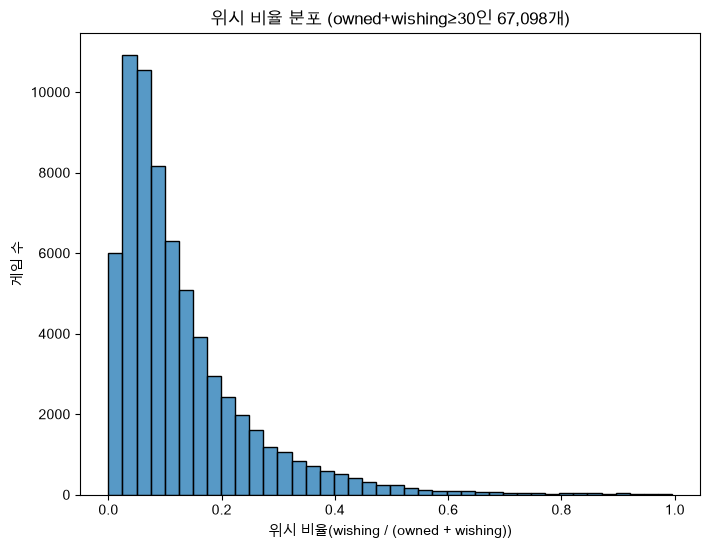

,name,yearpublished,averageweight,wish_ratio,owned,wishing
29967,Class of '89,2026,3.00,0.995169,2,412
11732,Quantified,0,0.00,0.994030,2,333
15810,Catvale,2026,2.80,0.991489,2,233
29463,Arctica,2027,3.00,0.990017,6,595
14433,Shugendo,2026,0.00,0.989924,4,393
21062,DUST,2026,0.00,0.985075,1,66
21306,Triumph of Fascism,0,0.00,0.985075,1,66
15652,Restart,2026,3.25,0.984348,9,566
17402,Cubaneo,2026,0.00,0.984252,4,250
28362,Dune: Imperium – Conspiracy,2026,0.00,0.983333,21,1239


In [ ]:
MIN_SIGNAL = 30  # owned+wishing이 너무 작으면 비율이 불안정해 임계 이하는 제외
wo = wish_owned[wish_owned['owned'] + wish_owned['wishing'] >= MIN_SIGNAL].copy()
wo['wish_ratio'] = wo['wishing'] / (wo['owned'] + wo['wishing'])

plt.figure(figsize=(8, 6))
sns.histplot(data=wo, x='wish_ratio', bins=40)
plt.title(f"위시 비율 분포 (owned+wishing≥{MIN_SIGNAL}인 {len(wo):,}개)")
plt.xlabel("위시 비율(wishing / (owned + wishing))")
plt.ylabel("게임 수")
plt.show()

wo.nlargest(20, 'wish_ratio')[['name', 'yearpublished', 'averageweight', 'wish_ratio', 'owned', 'wishing']]

In [ ]:
threshold = wo['wish_ratio'].quantile(0.9)
high_wish = wo[wo['wish_ratio'] >= threshold]
rest = wo[wo['wish_ratio'] < threshold]
print(f"상위 10% 평균 복잡도: {high_wish['averageweight'].mean():.2f} vs 나머지: {rest['averageweight'].mean():.2f}")

high_valid = high_wish[high_wish['yearpublished'] > 0]
rest_valid = rest[rest['yearpublished'] > 0]
print(f"상위 10% 평균 출시연도: {high_valid['yearpublished'].mean():.0f} vs 나머지: {rest_valid['yearpublished'].mean():.0f}")
print(f"상위 10% 중 yearpublished 결측(0) 비율: {(high_wish['yearpublished'] <= 0).mean():.1%} vs 나머지: {(rest['yearpublished'] <= 0).mean():.1%}")

상위 10% 평균 복잡도: 1.73 vs 나머지: 1.57
상위 10% 평균 출시연도: 2016 vs 나머지: 2011
상위 10% 중 yearpublished 결측(0) 비율: 1.6% vs 나머지: 0.7%


**결과**
- 위시 비율 상위 10% 게임의 평균 복잡도 1.73, 평균 출시연도 2016년, `yearpublished` 결측 비율 1.6%로 확인
- 위시리스트에만 쌓이는 게임은 비교적 최근에 나온, 조금 더 복잡한 게임 쪽으로 쏠리는 경향으로 나타남
    - 다만 그 차이의 크기 자체는 크지 않음


**"샀는데 안 한 게임" — 미플레이 비율**

- 소유자 중 한 번도 안 한 사람의 비율(정확히는 "기록이 없는" 사람이지만 8-0에서 확인했듯 오차가 작아 "안 함"으로 쓴다).
- 가설: 위시 비율 높은 게임 = 미플레이 비율도 높다

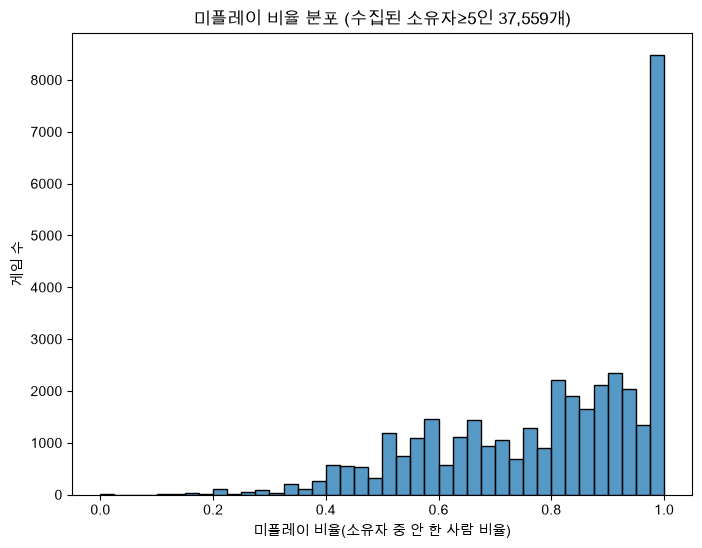

,name,yearpublished,averageweight,no_record_rate,n_sample_owners
20,Black Rose Wars: Rebirth – Rotas Box,2023,4.0000,1.0,26
27,Kabuto Sumo: Swarm,2024,0.0000,1.0,38
55,Mindbug: Tag Team,2025,3.0000,1.0,28
108,Tang Garden: Golden Cat,2024,0.0000,1.0,28
128,Blood Reef: Tarawa,1999,4.3750,1.0,26
170,"Warhammer 40,000: Codex",1994,3.4000,1.0,134
198,The Lord of the Rings: The Card Game – The Two...,2023,3.3333,1.0,30
204,Twinkle Twinkle: How I Wonder Expansion,2025,2.0000,1.0,31
299,Tainted Grail: Kings of Ruin – Black Goat of t...,2023,0.0000,1.0,34
364,Dune: War for Arrakis – Desert War,2026,3.6667,1.0,37


In [ ]:
ws = wish_owned[wish_owned['n_sample_owners'] >= 5].copy()
ws['no_record_rate'] = ws['n_sample_unplayed'] / ws['n_sample_owners']

plt.figure(figsize=(8, 6))
sns.histplot(data=ws, x='no_record_rate', bins=40)
plt.title(f"미플레이 비율 분포 (수집된 소유자≥5인 {len(ws):,}개)")
plt.xlabel("미플레이 비율(소유자 중 안 한 사람 비율)")
plt.ylabel("게임 수")
plt.show()

ws.nlargest(20, 'no_record_rate')[['name', 'yearpublished', 'averageweight', 'no_record_rate', 'n_sample_owners']]

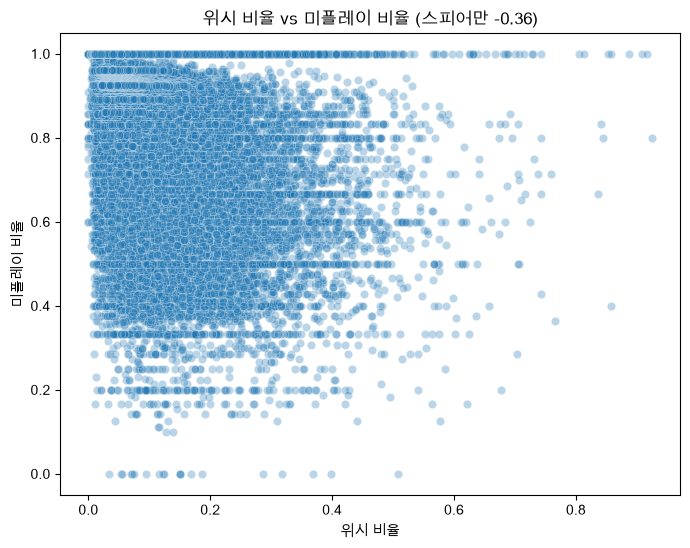

,column,method,correlation,p_value,abs_corr,significant
0,wish_ratio,spearman,-0.3578,0.0,0.3578,True


In [ ]:
overlap_check = wo.merge(ws[['objectid', 'no_record_rate']], on='objectid', how='inner')
corr_ws_result = AdvanceEDA.check_correlation(overlap_check[['wish_ratio', 'no_record_rate']], target='no_record_rate', method='spearman')
corr_s_ws = corr_ws_result['correlation'].iloc[0]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=overlap_check, x='wish_ratio', y='no_record_rate', alpha=0.3)
plt.title(f"위시 비율 vs 미플레이 비율 (스피어만 {corr_s_ws:.2f})")
plt.xlabel("위시 비율")
plt.ylabel("미플레이 비율")
plt.show()

corr_ws_result

In [ ]:
# 단순 신작 효과인지 확인: wish_ratio가 출시연도·복잡도·인기도로 설명되는 관계인지 함께 본다
# overlap_check는 이미 wo(wish_owned 파생)에서 온 yearpublished/averageweight/owned를 갖고 있다 — 재조인하지 않는다.
factor_valid = overlap_check[overlap_check['averageweight'] > 0].copy()
display(factor_valid[['wish_ratio', 'no_record_rate', 'yearpublished', 'averageweight', 'owned']].corr(method='spearman').round(2))

factor_valid['yb'] = pd.cut(factor_valid['yearpublished'], [1980, 2000, 2010, 2015, 2020, 2027])
factor_valid.groupby('yb', observed=True)['no_record_rate'].mean().round(3)

,wish_ratio,no_record_rate,yearpublished,averageweight,owned
wish_ratio,1.00,-0.36,0.29,0.12,-0.11
no_record_rate,-0.36,1.00,-0.14,0.31,-0.22
yearpublished,0.29,-0.14,1.00,0.02,0.15
averageweight,0.12,0.31,0.02,1.00,0.10
owned,-0.11,-0.22,0.15,0.10,1.00


yb
(1980, 2000]    0.831
(2000, 2010]    0.766
(2010, 2015]    0.790
(2015, 2020]    0.760
(2020, 2027]    0.724
Name: no_record_rate, dtype: float64

**결과**
- 위시 비율과 미플레이 비율의 스피어만 상관 -0.36으로, 음의 관계가 확인됨
- 이는 상관관계일 뿐 인과로 해석하지 않는다
    - "화제성이 높아서", "관심이 높아 바로 플레이한다", "오래된 게임은 방치된다" 같은 설명은 이 데이터로 증명할 수 없어, 두 지표가 서로 반대 방향으로 움직인다는 관측 사실까지만 남긴다
- `wish_ratio`와 `yearpublished`의 상관을 함께 보면 단순 신작 효과만으로는 전부 설명되지 않는 것으로 나타남
    - 03에서 세그먼트별로 더 뜯어본다


<a id="sec-10"></a>
## 10. 소수가 전체를 이끄는가

- 유저 활동량과 게임 소유량이 얼마나 쏠려 있는지 확인한다.

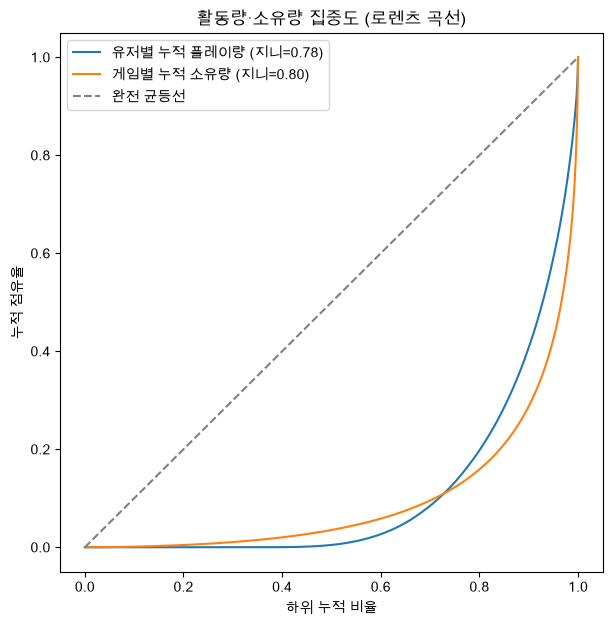

상위 10% 유저가 전체 플레이의 59.3%를 차지
상위 10% 게임이 전체 소유의 71.2%를 차지


In [ ]:
def gini(values):
    v = np.sort(values.to_numpy())
    n = len(v)
    cum = np.cumsum(v)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

def lorenz_curve(values):
    v = np.sort(values.to_numpy())
    cum = np.insert(np.cumsum(v) / v.sum(), 0, 0)
    pop_share = np.linspace(0, 1, len(cum))
    top10_share = 1 - np.interp(0.9, pop_share, cum)
    return pop_share, cum, top10_share

pop_share_user, lorenz_user, top10_user_share = lorenz_curve(by_user["total_numplays"])
pop_share_game, lorenz_game, top10_game_share = lorenz_curve(item["owned"])

plt.figure(figsize=(7, 7))
plt.plot(pop_share_user, lorenz_user, label=f"유저별 누적 플레이량 (지니={gini(by_user['total_numplays']):.2f})", color="#1f77b4")
plt.plot(pop_share_game, lorenz_game, label=f"게임별 누적 소유량 (지니={gini(item['owned']):.2f})", color="#ff7f0e")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="완전 균등선")
plt.title("활동량·소유량 집중도 (로렌츠 곡선)")
plt.xlabel("하위 누적 비율")
plt.ylabel("누적 점유율")
plt.legend()
plt.show()

print(f"상위 10% 유저가 전체 플레이의 {top10_user_share:.1%}를 차지")
print(f"상위 10% 게임이 전체 소유의 {top10_game_share:.1%}를 차지")

**결과**
- 지니계수는 유저 플레이량 0.78, 게임 소유량 0.80으로 확인(dedup 반영 후 수치, 1에 가까울수록 소수 집중)
    - 둘 다 매우 높은 불평등 수준
- 상위 10% 유저가 전체 플레이량의 59.3%를, 상위 10% 게임이 전체 소유의 71.2%를 차지하는 것으로 확인
- 평균 한 명으로 유저를 설명할 수 없을 만큼 행동량이 극단적으로 쏠려 있다는 것을 보여줌
- 그렇기 때문에 03에서 유저를 평균이 아닌 세그먼트 단위로 나눠 분석한다


<a id="sec-11"></a>
## 11. 핵심 지표 선정

- **퍼널 3단계**(보유→플레이함→반복 플레이)
    - `own=1`로만 수집했으므로(1-5) 퍼널은 소유에서 시작
    - Core User는 퍼널이 아니라 별도 세그먼트(8-1)
- **보유 게임 수**
    - 플레이 전환율과 가장 강한 관계를 보인 후보 변수(9-1)
    - 다만 보유 게임이 많을수록 1회 이상 플레이 조건을 채우기 쉬워지는 기계적 효과가 섞여 있어 인과로 해석하지 않는다
- **마지막 로그인 경과일**
    - 원인 변수가 아니라 현재 활동성 상태를 나타내는 보조 변수(9-2)
- **평가 참여율**
    - 퍼널 단계가 아닌 참여(engagement) 보조지표(8-3)
    - 최상위 분위의 플레이 비율이 오히려 최저(41.4%)로 확인된 비단조 지표
- **코호트 리텐션(실제 플레이 로그)**
    - `numplays`가 아니라 `user_play`의 개별 플레이 날짜로 시점을 재구성
    - 실제 인원은 1,065명이 아니라 730명(1-6)
- **세그먼트(소유 게임 수 기준)**
    - 활동량 지니계수가 0.78~0.80로 극단적으로 쏠려 있어(10) 소수/다수를 나누는 분할이 필요
- **복잡도**(`averageweight`)
    - BGG API가 제공하는 유일한 진입장벽 지표
    - 0값은 결측이므로 반드시 제외하고 사용(2-2, 4-2)
- **인기도**(BGG 전체 `owned`)
    - 잘 알려진 게임과 니치 게임을 구분하는 유일한 축(9-4, 단조 관계)
- **`bayesaverage`**
    - `usersrated ≥ 30`에서만 사용
    - 미만이면 미산출로 처리(2-2 항목 D, 4-2)
- **효과크기**(Cramér's V, Cohen's h, rank-biserial r 등)
    - 수십만 행 데이터에서는 p-값이 항상 유의하게 나오므로 반드시 함께 확인

**뺀 것**:
- `playingtime`은 결측 12.4%에 왜도 107.7로 극단적이라(2-3) 핵심 지표에서 제외
- `yearpublished`(게임 축)는 플레이 비율과 관계가 미미해(9-5, 25.6~31.7%) 후보에서 탈락
- `item_link`의 가족·확장판·아티스트 등(2-4)은 세그먼트 차이의 보조 설명으로만 쓰고 주 지표로 삼지 않는다


<a id="sec-12"></a>
## 12. EDA 결론

- 전체 유저 중 보유 게임이 있는지 확인할 수 있다는 것을 확인(3,000명 → 2,944명, 1-5·4-1)
- `user_item`으로 보유 게임을 실제로 했는지 확인할 수 있다는 것을 확인(1,988명)
    - `numplays`가 BGG 플레이 로그와 사실상 동일한 소스임을 8-0에서 검증
    - 동시에 기록하지 않은 플레이는 보이지 않는다는 한계도 함께 확정
- 반복해서 한 것과 한 번만 한 것을 구분할 수 있다는 것을 확인(1,850명)
    - 시점 정보가 없어 이를 지속 참여·리텐션으로 부르지 않으며, 시간적 지속성은 [Trend 분석](04.Trend.ipynb)에서 `user_play`로 별도로 본다
- `user_rating`은 시점이 없어 퍼널의 순차 단계로 쓸 수 없다는 것을 확인, 참여(engagement) 보조지표로 분리한다
    - (평가 참여율 최상위 분위의 플레이 비율이 오히려 41.4%로 최저인 비단조 패턴, 8-3)
- `user_play`는 전체 유저 데이터가 아니라는 것을 확인(730명, 1-6·4-3), 퍼널 분모로는 쓰지 않고 [Trend 분석](04.Trend.ipynb)의 시간축 분석에 활용한다
- 유저별 행동량이 크게 편중돼 있다는 것을 확인(지니 0.78~0.80, 10)
    - 평균만으로는 유저를 설명하기 어렵기 때문에, 이후 세그먼트가 필요하다

| 발견 | 근거 | 이어지는 곳 |
|---|---|---|
| `numplays`는 BGG 플레이 로그와 사실상 동일(오차 0.5% 미만), 이후 "안 함"으로 쓰지만 정확히는 "기록 없음" | 8-0 | [Funnel 분석](02.Funnel_Retention.ipynb)~[Trend 분석](04.Trend.ipynb) 전 구간 해석 원칙 |
| 퍼널 3단계 실측, 가장 큰 관측상 감소는 보유→플레이함(-32.5%p) | 8-1, 8-2 | [Funnel 분석](02.Funnel_Retention.ipynb)의 우선 분석 대상 |
| Core User는 퍼널 단계가 아니라 분위수 컷오프 세그먼트 | 8-1 | [Funnel 분석](02.Funnel_Retention.ipynb)·[Segment 분석](03.Segment_Wishlist.ipynb)에서 퍼널과 분리해서 다룰 것 |
| 보유 게임 수·인기도·복잡도가 플레이 여부와 관계 있음(인과 아님), 출시연도는 무관 | 9-1~9-5 | [Funnel 분석](02.Funnel_Retention.ipynb)·[Segment 분석](03.Segment_Wishlist.ipynb) |
| 평가 참여율은 퍼널 단계가 아닌 별도 engagement 축(비단조) | 8-3 | [Segment 분석](03.Segment_Wishlist.ipynb) |
| 복잡도 5분위 데이터 커버리지 확인, 2025·26년 가입자 포함 | 5 | 데이터 편향 점검 |
| 가입연도 흐름에 뚜렷한 정체·감소 구간이 있음(인과는 단정하지 않음) | 1-4 | [Funnel 분석](02.Funnel_Retention.ipynb) 코호트 해석 |
| 0으로 채운 결측 마커가 5개 컬럼에서 반복(`averageweight`·`bayesaverage`·`minage`·`stddev`·`length`) | 2-2, 4-2 | [Funnel 분석](02.Funnel_Retention.ipynb)~[Trend 분석](04.Trend.ipynb) 전 구간(값 그대로 쓰면 안 됨) |
| `user_item` 중복 13,861쌍 → dedup 규칙 확정(최신행+rating 백필) | 4-1 | [Funnel 분석](02.Funnel_Retention.ipynb)~[Trend 분석](04.Trend.ipynb) 유저 단위 집계 전부 |
| 정규성 전부 기각 → 스피어만 사용(p-값 외 근거 추가) | 2-3 | 방법론 |
| `bayesaverage=0`(미산출) 제외 시 상관 구조가 달라짐(예: stddev 관계 부호 반전) | 6-2 | 히트맵 해석 시 주의 |
| 복잡도-평점 상관 0.28→0.41(미산출 제외 후), 복잡도-권장연령·평점-호불호 등은 뚜렷 | 6-2, 6-4 | 09 후보 변수와 연결 |
| 유저 개인의 평점 성향(후한지 박한지) 확인 | 6-3 | [Segment 분석](03.Segment_Wishlist.ipynb) |
| 위시 비율 ↔ 미플레이 비율 음의 상관(-0.36), 인과 해석은 보류 | 9-6 | [Segment 분석](03.Segment_Wishlist.ipynb) |
| 활동량·소유량 극단 편중(지니 0.78~0.80) | 10 | [Segment 분석](03.Segment_Wishlist.ipynb) 분할 근거 |
| `item_link`/`item_rank`에 뷰 없는 축 다수(가족·확장판 등 7종) | 2-4 | [Trend 분석](04.Trend.ipynb) 필요 시 직접 쿼리 |
| `user_wishlist` 수집 완료(1,884명), 퍼널엔 미사용 | 1-7 | [Segment 분석](03.Segment_Wishlist.ipynb) 자산 |

**다음**:
- 따라서 [Funnel 분석](02.Funnel_Retention.ipynb)에서는 전체 `user_item` 기반으로 보유 → 플레이함 → 반복 플레이 퍼널을 구축해 가장 큰 관측상 감소 구간을 확인하고, Core User는 퍼널과 분리된 세그먼트로 함께 살펴본다
- [Segment 분석](03.Segment_Wishlist.ipynb)에서는 그 구간에 속한 유저의 특성을 세그먼트로 분석하며, [Trend 분석](04.Trend.ipynb)에서는 `user_play`를 활용해 시간적 지속성과 리텐션을 분석한다.
